# Section 1: Clean the dataset  (in this section, insert as many cells as needed) 

In [1]:
# Merge the yearly source files (large: ~850 MB combined)

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import plotly.express as px
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown


#df1 = pd.read_csv("2023.csv", encoding='latin1',low_memory=False)
#df2 = pd.read_csv("2024.csv", encoding='latin1',low_memory=False)

# Check if the columns are identical for the customer_order_number.1, This needs to happen before the merger!!!
#are_identical = df2['customer_order_number'].equals(df2['customer_order_number.1'])
#print(f"\nAre the columns identical? {are_identical}")

# If they contain the same data, then drop the duplicate column else nothing!
#if are_identical:
#    print("Dropping the duplicate column 'customer_order_number.1'")
#    df2 = df2.drop(columns=['customer_order_number.1'])

# Combine them vertically and merging the two files together.
#df = pd.concat([df1, df2], ignore_index=True)

#dropping the empty columns after a quick look
#df = df.drop(columns=['dss_update_time','item_source_class'])

#print(df.shape)
#df.head()
#Saving to another file called group_joined_dirty.csv
#df.to_csv('group_joined_dirty.csv', index=False)

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import plotly.express as px
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown

# Importing the beast as one piece.
df = pd.read_csv("group_joined_dirty.csv", low_memory=False)

pd.set_option('display.max_columns', None)
# Dropping the duplicates after import
df.drop_duplicates(inplace=True)
df = df[df.isna().sum(axis=1) < 18]

df.info(show_counts=True)



# Check for missing values in all columns
missing_values = df.isna().sum()
display(Markdown("#### Missing values per column before clean:"))
print(missing_values)


# First convert to float, then to Int64 to save headaches with these columns
df['value_sales'] = pd.to_numeric(df['value_sales'], errors='coerce') # We had the .replace(0, np.nan) extension before that the 0 be converted to null. this was a disaster
df['value_cost'] = pd.to_numeric(df['value_cost'], errors='coerce') # We had the .replace(0, np.nan) extension before that the 0 be converted to null. this was a disaster
df['value_quantity'] = pd.to_numeric(df['value_quantity'], errors='coerce') # We had the .replace(0, np.nan) extension before that the 0 be converted to null. this was a disaster
df['customer_code'] = pd.to_numeric(df['customer_code'], errors='coerce').astype('Int64')
df['fiscal_year'] = pd.to_numeric(df['fiscal_year'], errors='coerce').astype('Int64')
df['fiscal_month'] = pd.to_numeric(df['fiscal_month'], errors='coerce').astype('Int64')
df['company_code'] = pd.to_numeric(df['company_code'], errors='coerce').astype('Int64')
df['item_type'] = pd.to_numeric(df['item_type'], errors='coerce').astype('Int64')
df['invoice_number'] = pd.to_numeric(df['invoice_number'], errors='coerce').astype('Int64')
df['customer_order_number'] = pd.to_numeric(df['customer_order_number'], errors='coerce').astype('Int64')
df['customer_district_code'] = pd.to_numeric(df['customer_district_code'], errors='coerce').astype('Int64')




# Showing rows with missing values
display(Markdown("#### Show, don't tell:"))
rm = df[df.isna().any(axis=1)]
display(rm)
df.info(show_counts=True)

## Check the missing values

In [3]:
# Clean and convert date columns
# Replace invalid leap day (choose one approach: either inplace or reassignment)
df.replace(20230229, 20230228, inplace=True)  # Using inplace=True

#Fixing the date columns
# Convert numeric date columns
df['order_date'] = pd.to_datetime(df['order_date'].astype('Int64').astype(str), format='%Y%m%d', errors='coerce')
df['accounting_date'] = pd.to_numeric(df['accounting_date'], errors='coerce').astype('Int64')
df['invoice_date'] = pd.to_numeric(df['invoice_date'], errors='coerce').astype('Int64')

# Replace invalid leap day (choose one approach: either inplace or reassignment)
df.replace(20230229, 20230228, inplace=True)  # Using inplace=True

# Convert to datetime
df['accounting_date'] = pd.to_datetime(df['accounting_date'], format='%Y%m%d', errors='coerce')
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%Y%m%d', errors='coerce')


#Fixing the order_date
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month

# Replace order_date with invoice_date only where order_year == 2004
df.loc[df['order_year'] == 2004, 'order_date'] = df.loc[df['order_year'] == 2004, 'invoice_date']
# Replace order_date with invoice_date only where order_year == null
df.loc[df['order_date'].isnull(), 'order_date'] = df.loc[df['order_date'].isnull(), 'invoice_date']
#Fixing the fiscal month
df['fiscal_month'] = df['fiscal_month'].replace([13], 12)

# Replace order_date with invoice_date only where order_year == 2021
#df.loc[df['order_year'] == 2021, 'order_date'] = df.loc[df['order_year'] == 2021, 'invoice_date']
# Replace order_date with invoice_date only where order_year == 2022
#df.loc[df['order_year'] == 2022, 'order_date'] = df.loc[df['order_year'] == 2022, 'invoice_date']
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month

#Fixing the fiscal dates
mask = df['fiscal_year'].isnull() | df['fiscal_month'].isnull()

df.loc[mask, 'fiscal_year'] = np.where(
    df.loc[mask, 'accounting_date'].dt.month >= 7,
    df.loc[mask, 'accounting_date'].dt.year + 1,
    df.loc[mask, 'accounting_date'].dt.year
)

df.loc[mask, 'fiscal_month'] = df.loc[mask, 'accounting_date'].dt.month.apply(
    lambda m: m - 6 if m >= 7 else m + 6
)

#Giving the fiscal month a name column 
fiscal_month_map = {
    1: 'July', 2: 'August', 3: 'September', 4: 'October', 5: 'November', 6: 'December',
    7: 'January', 8: 'February', 9: 'March', 10: 'April', 11: 'May', 12: 'June'
}

df['fiscal_month_name'] = df['fiscal_month'].map(fiscal_month_map)


#Checking the others
df['account_year'] = df['accounting_date'].dt.year
df['account_month'] = df['accounting_date'].dt.month
df['invoice_year'] = df['invoice_date'].dt.year
df['invoice_month'] = df['invoice_date'].dt.month
#Dropping the not needed columns. If you want them again then just put in a # in front of the below code
#df = df.drop(columns=['order_year','order_month','invoice_month','invoice_year']) #,'account_month','account_year'

In [4]:
#Cleaning the Customer District code and giving it names

#if Customer_code starts with a:
#4 & 5 and is 9 long then customer district code = 200
#6 & 7 and is 9 long then customer district code = 300
#8 and is 9 long then customer district code = 400
#11 and is 10 long then customer district code = 500
#13 and is 10 long then customer district code = 600
#442200600 and is 9 long then customer district code = 720
#Just find the invoice number 

#Fixing up the customer district code using Assigment 1 as a reference
#making nulls
df['customer_district_code'] = df['customer_district_code'].replace(['na', 'Na',], np.nan)


#Metadata does not show the customer code 100, 
#review and investigation showed that this can be intuited as the company was also under the 200 code for Sydney warehouse_code 5N1 (padstow)
#They all share simliar invoice numbers and look to be, the same client SalesPro Accounts. So happy to have it from sydney.
corrections3 = {100:200}
df['customer_district_code'] = df['customer_district_code'].replace(corrections3)

# Create a dictionary to map customer codes to their district codes based on the customer number
code_to_district_map = {
    598961420: 200,
    602001410: 300,
    824603006: 400,
    722000816: 300,
    942300024: 400,
    722001008: 300,
    824200202: 400,
    822097802: 410,
    801200600: 400,
    461301230: 200,
    1014600200: 500,
    661200614: 300,
    423680802: 210,
    1021801202: 500,
    433972600: 200,
    514000200: 200,
    622001444: 300,
    537201404: 210,
    622201602: 300,
    598961440: 200
}

# Then we identify all rows that need updating
# This mask finds rows where the district code is null AND the customer code is one of the keys in our map
mask = (df['customer_district_code'].isnull()) & (df['customer_code'].isin(code_to_district_map.keys()))

# After whihch use the map to fill the nulls for the selected rows
df.loc[mask, 'customer_district_code'] = df.loc[mask, 'customer_code'].map(code_to_district_map)

#More cleaning please for the last lot that are null, I was looking at the order number to fill in the gaps...
df.loc[(df['customer_order_number'] == 555990) & (df['customer_district_code'].isnull()), 'customer_district_code'] = 400
df.loc[(df['customer_order_number'] == 1702888) & (df['customer_district_code'].isnull()), 'customer_district_code'] = 400

#Attaching the names of customer locations to the actual City/Region Names from the metadata
df.loc[df['customer_district_code'] == 200, 'customer_district_name'] = 'Sydney'
df.loc[df['customer_district_code'] == 210, 'customer_district_name'] = 'Act/riverina'
df.loc[df['customer_district_code'] == 300, 'customer_district_name'] = 'Melbourne'
df.loc[df['customer_district_code'] == 310, 'customer_district_name'] = 'Tasmania'
df.loc[df['customer_district_code'] == 400, 'customer_district_name'] = 'Brisbane'
df.loc[df['customer_district_code'] == 410, 'customer_district_name'] = 'Townsville'
df.loc[df['customer_district_code'] == 500, 'customer_district_name'] = 'Adelaide'
df.loc[df['customer_district_code'] == 510, 'customer_district_name'] = 'Darwin'
df.loc[df['customer_district_code'] == 520, 'customer_district_name'] = 'LuminaTech NZ - Nz'
df.loc[df['customer_district_code'] == 530, 'customer_district_name'] = 'South Island - Nz'
df.loc[df['customer_district_code'] == 535, 'customer_district_name'] = 'Central Region - Nz'
df.loc[df['customer_district_code'] == 540, 'customer_district_name'] = 'Northern Region - Nz'
df.loc[df['customer_district_code'] == 545, 'customer_district_name'] = 'Head Office Nz'
df.loc[df['customer_district_code'] == 600, 'customer_district_name'] = 'Perth'
df.loc[df['customer_district_code'] == 710, 'customer_district_name'] = 'Head Office Sales'
df.loc[df['customer_district_code'] == 720, 'customer_district_name'] = 'Intercompany Sales'

#Check the missing value in this column again: 
missing_customer_district_code = df[df['customer_district_code'].isna()]
missing_customer_district_code

In [5]:
#Fixing the company_code column using the customer order number
# Method: Fixing the missing values using the customer order number

df.loc[(df['customer_order_number'] == 5662478) & (df['company_code'].isnull()),'company_code'] = 205
df.loc[(df['customer_order_number'] == 555990) & (df['company_code'].isnull()),'company_code'] = 205
df.loc[(df['customer_order_number'] == 1702888) & (df['company_code'].isnull()),'company_code'] = 205
df.loc[(df['customer_order_number'] == 1772408) & (df['company_code'].isnull()),'company_code'] = 205 
df.loc[(df['customer_order_number'] == 1728266) & (df['company_code'].isnull()),'company_code'] = 205
df.loc[(df['customer_order_number'] == 1648032) & (df['company_code'].isnull()),'company_code'] = 205
df.loc[(df['customer_order_number'] == 1771646) & (df['company_code'].isnull()),'company_code'] = 205


#Check the missing value in this column again:
missing_customer_order_number = df[df['customer_order_number'].isna()]
missing_customer_order_number

# We will leave the missing values in this column here, and continue filling in later

In [6]:
# Strip whitespace from item codes. Notes:
#There are a lot of items here only having a few values. Are they made to order? I wonder what their margins on these would be?
#There is some items that are only numbers as well, why?
#Leaving this as is for now.

df['item_code'] = df['item_code'].str.strip()

In [7]:
#Fixing business_chain_l1_code
#Stripping business_chain_l1_code
df['business_chain_l1_code'] = df['business_chain_l1_code'].str.strip()
#Fixing the null values
df['business_chain_l1_code'] = df['business_chain_l1_code'].replace(['na', 'Na','na','NA'], np.nan)

#Filling in the null values with the customer order number
df.loc[(df['business_chain_l1_name'] == 'Aussie Energy Group') & (df['business_chain_l1_code'].isnull()),'business_chain_l1_code'] = 'AEG'
df.loc[(df['business_chain_l1_name'] == 'Independent Retailers Association') & (df['business_chain_l1_code'].isnull()),'business_chain_l1_code'] = 'ZZ2'
#Dropping the rest of the rows as there is no sales data in there 
df = df[df['business_chain_l1_code'].notnull()]

#Check the missing value in this column again:
missing_business_chain_code = df[df['business_chain_l1_code'].isna()]
missing_business_chain_code

In [8]:
#Fixing Item_type column
df.loc[:, 'item_class_code'] = df['item_class_code'].str.strip()
df.loc[(df['item_class_code'] == 'LMP05') & (df['item_type'].isnull()),'item_type'] = 5
df.loc[(df['customer_order_number'] == 1702888) & (df['item_type'].isnull()),'item_type'] = 7

#Check the missing value in this column again:
missing_item_type = df[df['item_type'].isna()]
missing_item_type

In [9]:
# Fixing the company_code column using the customer order number
#df.loc[(df['business_chain_l1_name'] == 'SalesPro Accounts') & (df['customer_code'].isnull()),'customer_code'] = 442200600

In [10]:
#fix the currency column: 
# Method: Fixing the missing values using the customer order number

df.loc[:, 'currency'] = df['currency'].str.strip()
currency_fill_1 = df.loc[(df["customer_order_number"] == 1677106) & (df["currency"].notna()),"currency"].iloc[0]
df.loc[(df["customer_order_number"] == 1677106) & (df["currency"].isna()),"currency"] = currency_fill_1

#Fixing the sneaky AUS
df.loc[df['currency'] == 'AUS', 'currency'] = 'AUD'

#Fixing the sneaky nulls based on customer code
df.loc[(df['customer_code'] == 469500002) & (df['currency'] == ''),'currency'] = 'AUD'
df.loc[(df['customer_code'] == 249520200) & (df['currency'] == ''),'currency'] = 'AUD'

#Check the missing value in this column again:
missing_currency = df[df['currency'].isna()]
missing_currency


In [11]:
#fix item group code column: 
# Method: Fixing the missing values using the customer order number

item_group_code_fill_1 = df.loc[(df["customer_order_number"] == 1702888) & (df["item_group_code"].notna()),"item_group_code"].iloc[0]
df.loc[(df["customer_order_number"] == 1702888) & (df["item_group_code"].isna()),"item_group_code"] = item_group_code_fill_1

item_group_code_fill_2 = df.loc[(df["item_code"] == '10020') & (df["item_group_code"].notna()),"item_group_code"].iloc[0]
df.loc[(df["item_code"] == '10020') & (df["item_group_code"].isna()),"item_group_code"] = item_group_code_fill_2

item_group_code_fill_3 = df.loc[(df["item_code"] == '10059') & (df["item_group_code"].notna()),"item_group_code"].iloc[0]
df.loc[(df["item_code"] == '10059') & (df["item_group_code"].isna()),"item_group_code"] = item_group_code_fill_3

item_group_code_fill_4 = df.loc[(df["item_code"] == '11300') & (df["item_group_code"].notna()),"item_group_code"].iloc[0]
df.loc[(df["item_code"] == '11300') & (df["item_group_code"].isna()),"item_group_code"] = item_group_code_fill_4

#Check the missing value in this column again:
missing_item_group_code = df[df['item_group_code'].isna()]
missing_item_group_code

In [12]:
#fix item class code column: 
# Method: Fixing the missing values using the customer order number

df.loc[:, 'item_group_code'] = df['item_group_code'].str.strip()
item_class_code_fill_1 = df.loc[(df["item_code"] == '11105') & (df["item_class_code"].notna()),"item_class_code"].iloc[0]
df.loc[(df["item_code"] == '11105') & (df["item_class_code"].isna()),"item_class_code"] = item_class_code_fill_1

item_class_code_fill_2 = df.loc[(df["item_code"] == '10399') & (df["item_class_code"].notna()),"item_class_code"].iloc[0]
df.loc[(df["item_code"] == '10399') & (df["item_class_code"].isna()),"item_class_code"] = item_class_code_fill_2

item_class_code_fill_3 = df.loc[(df["item_group_code"] == 'SUR02001') & (df["item_class_code"].notna()),"item_class_code"].iloc[0]
df.loc[(df["item_group_code"] == 'SUR02001') & (df["item_class_code"].isna()),"item_class_code"] = item_class_code_fill_3

item_class_code_fill_4 = df.loc[(df["item_group_code"] == 'LMP02001') & (df["item_class_code"].notna()),"item_class_code"].iloc[0]
df.loc[(df["item_group_code"] == 'LMP02001') & (df["item_class_code"].isna()),"item_class_code"] = item_class_code_fill_4

#Check the missing value in this column again:
missing_item_class_code = df[df['item_class_code'].isna()]
missing_item_class_code

In [13]:
#fix business area code column: 

#fixing this before running the code
df.loc[:, 'business_area_code'] = df['business_area_code'].str.strip()
df['business_area_code'] = df['business_area_code'].replace(['nan'], np.nan)
# Create a copy to avoid modifying the original accidentally
# Fixed 'stisna' typo - replaced with str slicing to get prefix
df['item_group_prefix'] = df['item_group_code'].astype(str).str[:3]  # Assuming prefix is first 3 characters

# Fill missing business_area_code where prefix is available
df['business_area_code'] = np.where(df['business_area_code'].isna(),df['item_group_prefix'],df['business_area_code'])

# Fix <NA to <NA>
df.loc[df['business_area_code'].astype(str).str.contains('<NA', case=False, na=False),'business_area_code'] = pd.NA

# Fill the missing values by with the same customer order number
business_area_fill = df.loc[(df["customer_order_number"] == 1702888) & (df["business_area_code"].notna()),"business_area_code"].iloc[0]

df.loc[(df["customer_order_number"] == 1702888) & (df["business_area_code"].isnull()),"business_area_code"] = business_area_fill

#Check the missing value in this column again:
missing_business_area_code = df[df['business_area_code'].isna()]
missing_business_area_code

In [14]:
#Fixing the bonuses for trade and professional
# Method: Fixing the missing values using the customer order number

df.loc[:, 'bonus_group_code'] = df['bonus_group_code'].str.strip()
df.loc[(df['customer_order_number'] == 1702888) & (df['bonus_group_code'].isnull()),'bonus_group_code'] = 'Trade'
df.loc[(df['customer_order_number'] == 1676638) & (df['bonus_group_code'].isnull()),'bonus_group_code'] = 'Trade'

#Check the missing value in this column again:
missing_bonus_group_code = df[df['bonus_group_code'].isna()]
missing_bonus_group_code

In [15]:
# Fix the invoice number column (still having 2 missing values - leave it to drop later: 
# Method: Fixing the missing values using the customer order number

invoice_number_fill_1 = df.loc[(df["customer_order_number"] == 1740982) & (df["invoice_number"].notna()),"invoice_number"].iloc[0]
df.loc[(df["customer_order_number"] == 1740982) & (df["invoice_number"].isna()),"invoice_number"] = invoice_number_fill_1

invoice_number_fill_2 = df.loc[(df["customer_order_number"] == 1693448) & (df["invoice_number"].notna()),"invoice_number"].iloc[0]
df.loc[(df["customer_order_number"] == 1693448) & (df["invoice_number"].isna()),"invoice_number"] = invoice_number_fill_2

invoice_number_fill_3 = df.loc[(df["customer_order_number"] == 1701370) & (df["invoice_number"].notna()),"invoice_number"].iloc[0]
df.loc[(df["customer_order_number"] == 1701370) & (df["invoice_number"].isna()),"invoice_number"] = invoice_number_fill_3

#Check the missing value in this column again:
missing_invoice_number = df[df['invoice_number'].isna()]
missing_invoice_number

In [16]:
#Fixing the commision_group_code, essentially just filling it in with the mode.
df.loc[:, 'commission_group_code'] = df['commission_group_code'].str.strip()
df.loc[df['commission_group_code'].isnull(), 'commission_group_code'] = 'NET_SALES'

#Check the missing value in this column again:
missing_commission_group_code = df[df['commission_group_code'].isna()]
missing_commission_group_code

In [17]:
#Fixing the business_chain_l1_code

df.loc[:, 'business_chain_l1_name'] = df['business_chain_l1_name'].str.strip()
#Fixing the na to null
df['business_chain_l1_name'] = df['business_chain_l1_name'].replace(['na', 'Na','na','NA'], np.nan)

df.loc[(df['business_chain_l1_code'] == 'MED') & (df['business_chain_l1_name'].isnull()),'business_chain_l1_name'] = 'Metro Electrical Distributors'
df.loc[(df['business_chain_l1_code'] == 'BPS') & (df['business_chain_l1_name'].isnull()),'business_chain_l1_name'] = 'BrightPower Solutions'
df.loc[(df['business_chain_l1_code'] == 'ZZ2') & (df['business_chain_l1_name'].isnull()),'business_chain_l1_name'] = 'Independent Retailers Association'
df.loc[(df['business_chain_l1_code'] == 'ZZ3') & (df['business_chain_l1_name'].isnull()),'business_chain_l1_name'] = 'ProLighting Specialists'
df.loc[(df['business_chain_l1_code'] == 'ZZZ') & (df['business_chain_l1_name'].isnull()),'business_chain_l1_name'] = 'General Suppliers Pty'

#Check the missing value in this column again:
missing_business_chain_name = df[df['business_chain_l1_code'].isna()]
missing_business_chain_name

In [18]:
#Fixing the contact_method_code by dropping it. We have reviewed it and it didn't seem to hold anything of value.

df = df.drop('contact_method_code', axis=1)

In [19]:
#Fixing the salesperson code
# Method: Fixing the missing values using the customer order number


df.loc[:, 'salesperson_code'] = df['salesperson_code'].str.strip()
#Fixing the null
df['salesperson_code'] = df['salesperson_code'].replace(['na', 'NA',], np.nan)
df.loc[(df['customer_order_number'] == 1734936) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'P237'
df.loc[(df['customer_order_number'] == 5987672) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'P248'
df.loc[(df['customer_order_number'] == 1740924) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'T400'
df.loc[(df['customer_order_number'] == 1648032) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'T200'
df.loc[(df['customer_order_number'] == 1704632) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'P200'
df.loc[(df['customer_order_number'] == 1745174) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'T204'
df.loc[(df['customer_order_number'] == 1645128) & (df['salesperson_code'].isnull()),'salesperson_code'] = 'P500'

#Check the missing value in this column again:
missing_salesperson_code = df[df['salesperson_code'].isna()]
missing_salesperson_code

In [20]:
#Fixing the order_type_code
# Method: Fixing the missing values using the customer order number or invoice number


df['order_type_code'] = df['order_type_code'].replace(['na', 'NA',], np.nan)
df.loc[(df['customer_order_number'] == 1766714) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'
df.loc[(df['invoice_number'] == 290161) & (df['order_type_code'].isnull()),'order_type_code'] = 'CRR'
df.loc[(df['customer_order_number'] == 5987672) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'
df.loc[(df['customer_order_number'] == 1663916) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'
df.loc[(df['customer_order_number'] == 1681010) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'
df.loc[(df['invoice_number'] == 734503) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'
df.loc[(df['customer_order_number'] == 1729130) & (df['order_type_code'].isnull()),'order_type_code'] = 'NOR'


#fixing the sillyness
df.loc[df['order_type_code'] == 'PM0', 'order_type_code'] = 'PMO'
#Giving them proper names:

df.loc[df['order_type_code'] == 'NOR', 'order_type_code_name'] = 'Normal Order'
df.loc[df['order_type_code'] == 'EDI', 'order_type_code_name'] = 'EDI Order'
df.loc[df['order_type_code'] == 'CDG', 'order_type_code_name'] = 'Credit Damaged Goods Not Returned'
df.loc[df['order_type_code'] == 'PRO', 'order_type_code_name'] = 'Project Order'
df.loc[df['order_type_code'] == 'NOS', 'order_type_code_name'] = 'Normal Order - Site Delivery Direct'
df.loc[df['order_type_code'] == 'CRR', 'order_type_code_name'] = 'Credit Goods Return'
df.loc[df['order_type_code'] == 'EXP', 'order_type_code_name'] = 'Export Order'
df.loc[df['order_type_code'] == 'EDS', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'CSH', 'order_type_code_name'] = 'Cash Order'
df.loc[df['order_type_code'] == 'PRD', 'order_type_code_name'] = 'Project Order - Site Delivery'
df.loc[df['order_type_code'] == 'CRD', 'order_type_code_name'] = 'Credit Price Only'
df.loc[df['order_type_code'] == 'NOH', 'order_type_code_name'] = 'Normal Order Head Office Sales'
df.loc[df['order_type_code'] == 'COP', 'order_type_code_name'] = 'Charge Only - Price Adjustment'
df.loc[df['order_type_code'] == 'OBS', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'MIN', 'order_type_code_name'] = 'Minimum Sell Override'
df.loc[df['order_type_code'] == 'COA', 'order_type_code_name'] = 'Charge Only - Stock Adjustment'
df.loc[df['order_type_code'] == 'PSA', 'order_type_code_name'] = 'Project Sample For Approval'
df.loc[df['order_type_code'] == 'PPD', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'WDC', 'order_type_code_name'] = 'Wrong Delivery Charge'
df.loc[df['order_type_code'] == 'PMO', 'order_type_code_name'] = 'Project Order - Brand B'
df.loc[df['order_type_code'] == 'CPR', 'order_type_code_name'] = 'Credit Project Goods Return'
df.loc[df['order_type_code'] == 'PME', 'order_type_code_name'] = 'Project Order Manufacturing & Engineering'
df.loc[df['order_type_code'] == 'CRP', 'order_type_code_name'] = 'Credit Project Price Only'
df.loc[df['order_type_code'] == 'PGS', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'SPL', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'AES', 'order_type_code_name'] = 'Brand C Only'
df.loc[df['order_type_code'] == 'ZCG', 'order_type_code_name'] = 'Credit Goods Return - Pnz Only'
df.loc[df['order_type_code'] == 'ZCR', 'order_type_code_name'] = 'Credit Price - Pnz Only'
df.loc[df['order_type_code'] == 'SPC', 'order_type_code_name'] = 'Specialty Order'
df.loc[df['order_type_code'] == 'ZOP', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'ZC2', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == '5TN', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'PUP', 'order_type_code_name'] = 'Pick Up Order'
df.loc[df['order_type_code'] == 'PPO', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'ZD3', 'order_type_code_name'] = '* Do Not Use *'
df.loc[df['order_type_code'] == 'CSO', 'order_type_code_name'] = '* Do Not Use *'

#Check the missing value in this column again:
missing_order_type_code = df[df['order_type_code'].isna()]
missing_order_type_code

In [21]:
# Fix the customer order number column (still having 2 missing values): To later be deleted and dropped. 
customer_order_number_fill_1 = df.loc[(df["invoice_number"] == 749789) & (df["customer_order_number"].notna()),"customer_order_number"].iloc[0]
df.loc[(df["invoice_number"] == 749789) & (df["customer_order_number"].isna()),"customer_order_number"] = customer_order_number_fill_1

#Check the missing value in this column again:
missing_customer_order_number = df[df['customer_order_number'].isna()]
missing_customer_order_number

In [22]:
# Fix the warehouse_code column: 
# Method: Fixing the missing values using the customer order number

warehouse_fill_1 = df.loc[(df["customer_order_number"] == 1733872) & (df["warehouse_code"].notna()),"warehouse_code"].iloc[0]
df.loc[(df["customer_order_number"] == 1733872) & (df["warehouse_code"].isna()),"warehouse_code"] = warehouse_fill_1

warehouse_fill_2 = df.loc[(df["customer_order_number"] == 6018420) & (df["warehouse_code"].notna()),"warehouse_code"].iloc[0]
df.loc[(df["customer_order_number"] == 6018420) & (df["warehouse_code"].isna()),"warehouse_code"] = warehouse_fill_2

warehouse_fill_3 = df.loc[(df["customer_order_number"] == 1745174) & (df["warehouse_code"].notna()),"warehouse_code"].iloc[0]
df.loc[(df["customer_order_number"] == 1745174) & (df["warehouse_code"].isna()),"warehouse_code"] = warehouse_fill_3

#Check the missing value in this column again:
missing_warehouse_code = df[df['warehouse_code'].isna()]
missing_warehouse_code

In [23]:
# Fix the abc_class_code column: 
# Method: Fixing the missing values using the customer order number

# Define the missing values in abc_class_code with customer order number = 1734936 and item_group_prefix = COM
abc_code_1 = df.loc[(df["customer_order_number"] == 1734936) & (df["item_group_prefix"] == "COM"), "abc_class_code"].dropna().iloc[0]
#replace it to the original data
df.loc[df["customer_order_number"]== 1734936,"abc_class_code"] = df.loc[df["customer_order_number"]== 1734936,"abc_class_code"].fillna(abc_code_1)

# Define the missing values
abc_code_2 = df.loc[(df["customer_order_number"] == 5936026), "abc_class_code"].dropna().iloc[0]
abc_code_2
#replace it to the original data
df.loc[df["customer_order_number"]== 5936026,"abc_class_code"] = df.loc[df["customer_order_number"]== 5936026,"abc_class_code"].fillna(abc_code_2)

#Check the missing value in this column again:
missing_abc_class_code = df[df['abc_class_code'].isna()]
missing_abc_class_code

In [24]:
# Fix the abc_class_volume column: 
# Method: Fixing the missing values using the customer order number


# Define the missing values
abc_volume_1 = df.loc[(df["customer_order_number"] == 1757532), "abc_class_volume"].dropna().iloc[0]
abc_volume_1
#replace it to the original data
df.loc[df["customer_order_number"]== 1757532,"abc_class_volume"] = df.loc[df["customer_order_number"]== 1757532,"abc_class_volume"].fillna(abc_volume_1)


# Define the missing values
abc_volume_2 = df.loc[(df["customer_order_number"] == 1648032), "abc_class_volume"].dropna().iloc[0]
abc_volume_2
#replace it to the original data
df.loc[df["customer_order_number"]== 1648032,"abc_class_volume"] = df.loc[df["customer_order_number"]== 1648032,"abc_class_volume"].fillna(abc_volume_2)

#Check the missing value in this column again:
missing_abc_class_volume = df[df['abc_class_volume'].isna()]
missing_abc_class_volume

In [25]:
# Fixing the environment group code column: 
# Method: Fixing the missing values using the customer order number

df.loc[:, 'environment_group_code'] = df['environment_group_code'].str.strip()
missing_egc = df[df['environment_group_code'].isna()]
missing_egc
df_filter = df[(df['customer_order_number'] == 1702888)]
df_filter
envi_fill = df.loc[(df["customer_order_number"] == 1702888) & (df["environment_group_code"].notna()),"environment_group_code"].iloc[0]
df.loc[(df["customer_order_number"] == 1702888) & (df["environment_group_code"].isna()),"environment_group_code"] = envi_fill

df_filter = df[(df['customer_order_number'] == 1679440)]
df_filter
envi_fill1 = df.loc[(df["customer_order_number"] == 1679440) & (df["environment_group_code"].notna()),"environment_group_code"].iloc[0]
envi_fill1
df.loc[(df["customer_order_number"] == 1679440) & (df["environment_group_code"].isna()),"environment_group_code"] = envi_fill1

#Check the missing value in this column again:
missing_environment_group_code = df[df['environment_group_code'].isna()]
missing_environment_group_code

In [26]:
#Fixing market segment
df['market_segment'] = df['market_segment'].replace(['na', 'NA',], np.nan)

df.loc[df['market_segment'].isnull(), 'market_segment'] = 'Commercial & Industrial'

#Check the missing value in this column again:
missing_market_segment = df[df['market_segment'].isna()]
missing_market_segment

In [27]:
#fixing light source:

df['light_source'] = df['light_source'].replace(['na', 'Na',], np.nan)
missing_light = df[df['light_source'].isna()]

ls1 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "LMP04"), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== "LMP04","light_source"] = df.loc[df["item_class_code"]== "LMP04","light_source"].fillna(ls1)

ls2 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "LMP02"), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== "LMP02","light_source"] = df.loc[df["item_class_code"]== "LMP02","light_source"].fillna(ls2)

ls3 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == '14001'), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== '14001',"light_source"] = df.loc[df["item_class_code"]== '14001',"light_source"].fillna(ls3)

ls4 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "COM03"), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'COM03',"light_source"] = df.loc[df["item_class_code"]== 'COM03',"light_source"].fillna(ls4)

ls5 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "LMP03"), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'LMP03',"light_source"] = df.loc[df["item_class_code"]== 'LMP03',"light_source"].fillna(ls5)

ls6 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "LMP05"), "light_source"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'LMP05',"light_source"] = df.loc[df["item_class_code"]== 'LMP05',"light_source"].fillna(ls6)

#Check the missing value in this column again:
missing_light = df[df['light_source'].isna()]
missing_light

In [28]:
#Cleaning Tech Group Code

uni_tech = df['technology_group_code'].unique()
df.loc[:, 'technology_group_code'] = df['technology_group_code'].str.strip()

uni_tech = df['technology_group_code'].unique()
missing_tech = df[df['technology_group_code'].isna()]

tg = df.loc[(df["item_type"] == 4) & (df["item_class_code"] == "COM99"), "technology_group_code"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'COM99',"technology_group_code"] = df.loc[df["item_class_code"]== 'COM99',"technology_group_code"].fillna(tg)

tg1 = df.loc[(df["item_type"] == 7) & (df["item_class_code"] == "LMP05"), "technology_group_code"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'LMP05',"technology_group_code"] = df.loc[df["item_class_code"]== 'LMP05',"technology_group_code"].fillna(tg1)

tg2 = df.loc[(df["item_type"] == 5) & (df["item_class_code"] == "LMP02"), "technology_group_code"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'LMP02',"technology_group_code"] = df.loc[df["item_class_code"]== 'LMP02',"technology_group_code"].fillna(tg2)

tg3 = df.loc[(df["item_type"] == 7) & (df["item_class_code"] == "LMP03"), "technology_group_code"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'LMP03',"technology_group_code"] = df.loc[df["item_class_code"]== 'LMP03',"technology_group_code"].fillna(tg3)

tg4 = df.loc[(df["item_type"] == 7) & (df["item_class_code"] == "LMP03"), "technology_group_code"].dropna().iloc[0]
df.loc[df["item_class_code"]== 'SUR02',"technology_group_code"] = df.loc[df["item_class_code"]== 'SUR02',"technology_group_code"].fillna(tg4)

#Check the missing value in this column again:
missing_tech = df[df['technology_group_code'].isna()]
missing_tech

In [29]:
#Fixing the reporting_classification
# Method: Fixing the missing values using the customer order number

df.loc[(df['customer_order_number'] == 1694342) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Continuing'
df.loc[(df['customer_order_number'] == 1702888) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Continuing'
df.loc[(df['customer_order_number'] == 1740924) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Discontinuing'
df.loc[(df['customer_order_number'] == 1704632) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Discontinuing'
df.loc[(df['customer_order_number'] == 1656836) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Discontinuing'
df.loc[(df['customer_order_number'] == 1655988) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Continuing'
df.loc[(df['customer_order_number'] == 1676638) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Continuing'
df.loc[(df['customer_order_number'] == 1677594) & (df['reporting_classification'].isnull()),'reporting_classification'] = 'Continuing'

#Check the missing value in this column again:
missing_reporting_classification = df[df['reporting_classification'].isna()]
missing_reporting_classification

In [30]:
#Needed this to make it work
df.loc[:, 'item_code'] = df['item_code'].astype(str).str.strip() # Added .astype(str) for safety

# --- Imputation for value_quantity ---
# Derive median using item_code
median_item_quant = df.groupby(['item_code'])['value_quantity'].median().reset_index()
# Check for rows where item_value_quanitity is missing
df.loc[df['value_quantity'].isna(), ['item_code','value_quantity','value_sales','value_cost']]

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "GENIE14WCDLBC", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "GENIE14WCDLBC", "value_quantity"] = \
    df.loc[df["item_code"] == "GENIE14WCDLBC", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "GENIE14WCDLES", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "GENIE14WCDLES", "value_quantity"] = \
    df.loc[df["item_code"] == "GENIE14WCDLES", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "GENIE11WWWBC", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "GENIE11WWWBC", "value_quantity"] = \
    df.loc[df["item_code"] == "GENIE11WWWBC", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "GENIE11WWWES", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "GENIE11WWWES", "value_quantity"] = \
    df.loc[df["item_code"] == "GENIE11WWWES", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "1000HPIBOXHF", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "1000HPIBOXHF", "value_quantity"] = \
    df.loc[df["item_code"] == "1000HPIBOXHF", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "11105", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "11105", "value_quantity"] = \
    df.loc[df["item_code"] == "11105", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "10056", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "10056", "value_quantity"] = \
    df.loc[df["item_code"] == "10056", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == "1000SONBOXHF", "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == "1000SONBOXHF", "value_quantity"] = \
    df.loc[df["item_code"] == "1000SONBOXHF", "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == '18081', "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == '18081', "value_quantity"] = \
    df.loc[df["item_code"] == '18081', "value_quantity"].fillna(iv_median)

# Impute using median of specific item_codes
# item_code median
iv_median = median_item_quant.loc[median_item_quant["item_code"] == 'nan', "value_quantity"].dropna().iloc[0]
# Fill missing values in the column 'value_quantity'
df.loc[df["item_code"] == 'nan', "value_quantity"] = \
    df.loc[df["item_code"] == 'nan', "value_quantity"].fillna(iv_median)

# show remaining NaNs in the subset
display(df.loc[df['value_quantity'].isna(), ['item_code', 'value_quantity', 'value_sales', 'value_cost']])


In [31]:
# --- Imputation for value_sales  ---
# Derive median using item_code
median_item_value = df.groupby(['item_code','value_quantity'])['value_sales'].median().reset_index()

# Check for rows where item_value is missing
df.loc[df['value_sales'].isna(), ['item_code', 'value_sales','value_quantity']]

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==4 ) & (median_item_value["item_code"] == "1000HPIBOXHF"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 4), "value_sales"] = df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 4), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==1 ) & (median_item_value["item_code"] == "1000HPIBOXHF"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 1), "value_sales"] = df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 1), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==6 ) & (median_item_value["item_code"] == "1000HPIBOXHF"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 6), "value_sales"] = df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 6), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==10 ) & (median_item_value["item_code"] == "10056"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10056') &(df["value_quantity"] == 10), "value_sales"] = df.loc[(df["item_code"] == '10056') &(df["value_quantity"] == 10), "value_sales"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==2 ) & (median_item_value["item_code"] == "11211"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '11211') &(df["value_quantity"] == 2), "value_sales"] = df.loc[(df["item_code"] == '11211') &(df["value_quantity"] == 2), "value_sales"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==2 ) & (median_item_value["item_code"] == "10399"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10399') &(df["value_quantity"] == 2), "value_sales"] = df.loc[(df["item_code"] == '10399') &(df["value_quantity"] == 2), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==30 ) & (median_item_value["item_code"] == "10058"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10058') &(df["value_quantity"] == 30), "value_sales"] = df.loc[(df["item_code"] == '10058') &(df["value_quantity"] == 30), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==2 ) & (median_item_value["item_code"] == "10364"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 2), "value_sales"] = df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 2), "value_sales"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==2 ) & (median_item_value["item_code"] == "10032"), "value_sales"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 2), "value_sales"] = df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 2), "value_sales"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = (111.8523 * 2.06 * 4) #used the same margin from 1130/03/DD4KIT1 and the unit costs associated with it
# Fill missing values in the column 
df.loc[(df["item_code"] == '1120/02/DD4KIT1') &(df["value_quantity"] == 4), "value_sales"] = df.loc[(df["item_code"] == '1120/02/DD4KIT1') &(df["value_quantity"] == 4), "value_sales"].fillna(vs_median) 

# show remaining NaNs in the subset
display(df.loc[df['value_sales'].isna(), ['item_code', 'value_quantity', 'value_sales', 'value_cost']])

In [32]:
# --- Imputation for value_cost  ---
# Derive median using item_code
median_item_value = df.groupby(['item_code','value_quantity'])['value_cost'].median().reset_index()

# Check for rows where item_value is missing
df.loc[df['value_cost'].isna(), ['item_code', 'value_cost','value_quantity','value_sales']]

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==1 ) & (median_item_value["item_code"] == "10311"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10311') &(df["value_quantity"] == 1), "value_cost"] = df.loc[(df["item_code"] == '10311') &(df["value_quantity"] == 1), "value_cost"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==14 ) & (median_item_value["item_code"] == "11154"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '11154') &(df["value_quantity"] == 14), "value_cost"] = df.loc[(df["item_code"] == '11154') &(df["value_quantity"] == 14), "value_cost"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==3 ) & (median_item_value["item_code"] == "10364"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 3), "value_cost"] = df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 3), "value_cost"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==20 ) & (median_item_value["item_code"] == "10364"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 20), "value_cost"] = df.loc[(df["item_code"] == '10364') &(df["value_quantity"] == 20), "value_cost"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==30 ) & (median_item_value["item_code"] == "10032"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 30), "value_cost"] = df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 30), "value_cost"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==2 ) & (median_item_value["item_code"] == "10032"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 2), "value_cost"] = df.loc[(df["item_code"] == '10032') &(df["value_quantity"] == 2), "value_cost"].fillna(vs_median)

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==1 ) & (median_item_value["item_code"] == "1000HPIBOXHF"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 1), "value_cost"] = df.loc[(df["item_code"] == '1000HPIBOXHF') &(df["value_quantity"] == 1), "value_cost"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==1 ) & (median_item_value["item_code"] == "1000SONBOXHF"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == '1000SONBOXHF') &(df["value_quantity"] == 1), "value_cost"] = df.loc[(df["item_code"] == '1000SONBOXHF') &(df["value_quantity"] == 1), "value_cost"].fillna(vs_median) 

# Impute using median of specific item_codes
# item_code median
vs_median = median_item_value.loc[(median_item_value["value_quantity"] ==6 ) & (median_item_value["item_code"] == "nan"), "value_cost"].dropna().iloc[0]
# Fill missing values in the column 
df.loc[(df["item_code"] == 'nan') &(df["value_quantity"] == 6), "value_cost"] = df.loc[(df["item_code"] == 'nan') &(df["value_quantity"] == 6), "value_cost"].fillna(vs_median) 

# show remaining NaNs in the subset
display(df.loc[df['value_cost'].isna(), ['item_code', 'value_quantity', 'value_sales', 'value_cost']])



In [35]:
df

In [33]:
df['value_sales'] = pd.to_numeric(df['value_sales'], errors='coerce') # We had the .replace(0, np.nan) extension before that the 0 be converted to null. this was a disaster
df['value_cost'] = pd.to_numeric(df['value_cost'], errors='coerce') # We had the .replace(0, np.nan) extension before that the 0 be converted to null. this was a disaster
df['value_quantity'] = pd.to_numeric(df['value_quantity'], errors='coerce')


In [34]:
# --- Imputation for value_price_adjustment  ---
#With added "make sure this is working"
df['value_price_adjustment'] = pd.to_numeric(df['value_price_adjustment'], errors='coerce').replace(0, np.nan)
df['value_price_adjustment'] = df['value_price_adjustment'].fillna(0)

In [36]:
#To fix the Item Code basically have to look really hard at the DF until it started making sence

df.loc[:, 'item_code'] = df['item_code'].str.strip()
df.loc[df['item_code'] == 'nan', 'item_code'] = None
#give the per unit 
df['item_value'] = df['value_sales'] / df['value_quantity']
df['item_cost'] = df['value_cost'] / df['value_quantity']

# This item is a mistake. It costs too much. It would be a duplicate if it wasn't for the cost. Dropping.
df.drop(df[(df['technology_group_code'] == 'SYLV') & (df['item_group_code'] == 'LMP01008') & (df['item_value'] == 3.35) & (df['customer_district_name'] == 'Sydney') & (df['customer_code'] == 598961420) & (df['item_code'].isnull())].index, inplace=True)

#Honestly this is and educated guess, this customer bought more GENIE18WWWES so changing this null to this.
df.loc[(df['technology_group_code'] == 'SYLV') & (df['item_group_code'] == 'LMP01008')  & (df['item_value'] == 3.09) & (df['customer_code'] == 598961440) & (df['item_code'].isnull()),'item_code'] = 'GENIE18WWWES'

#This customer_code bought mainly this GENIE14WCDLES at around this time.
df.loc[(df['technology_group_code'] == 'SYLV') & (df['item_group_code'] == 'LMP01008')  & (df['customer_code'] == 722000900) & (df['item_value'] == 3.35) & (df['item_code'].isnull()),'item_code'] = 'GENIE14WCDLES'

#closest price to 2.075 was 2.07 bringing the item code to 18081
df.loc[(df['item_group_code'] == '999') & (df['item_class_code'] == "14001") & (df['customer_district_name'] == 'Sydney') & (df['company_code'] == 205) & (df['technology_group_code']== 'NA') & (df['item_code'].isnull()),'item_code'] = 18081

#Pretty much built this one up from nearly no data at all.
df.loc[(df['customer_order_number'] == 1702888) & (df['item_code'].isnull()), 'item_code'] = 20585

#found using the following filter to be the item_code 100220
df.loc[(df['customer_code'] == 469500002) & (df['warehouse_code'] == '1N0') & (df['item_value']> 300) & (df['item_class_code'] == 'PEN01') & (df['item_code'].isnull()), 'item_code'] = 100220

#Found using this filter to be close enough to 10364 
df.loc[(df['item_group_code'] == 'COM03002') & (df['item_value'] == 7.3) & (df['item_code'].isnull()), 'item_code'] = 10364

#Easy find for this item code of 10399
df.loc[(df['item_group_code'] == 'COM03002') & (df['item_value'] == 33.75) & (df['item_code'].isnull()), 'item_code'] = 10399

#Closest find for this item code of with the value_cost 11094
df.loc[(df['item_group_code'] == 'LMP02001') & (df['item_value'] == 2.5) & (df['item_code'].isnull()), 'item_code'] = 11094

#Easy find for this item code of 11105
df.loc[(df['item_group_code'] == 'LMP02001') & (df['item_value'] == 3.510) & (df['technology_group_code'] == 'CROM') & (df['item_code'].isnull()), 'item_code'] = 11105

#Easy find for this item code of 1000SONBOXHF
df.loc[(df['item_group_code'] == 'COM99001') & (df['item_value'] == 405.38) & (df['technology_group_code'] == 'NA') & (df['item_code'].isnull()), 'item_code'] = '1000SONBOXHF'

#Easy find for this item code of 10028
df.loc[(df['item_group_code'] == 'LMP05002') & (df['item_value'] == 0.86) & (df['technology_group_code'] == '78') & (df['item_code'].isnull()), 'item_code'] = 10028

#Easy find for this item code of 10056
df.loc[(df['item_group_code'] == 'LMP05017') & (df['item_value'] == 1.458) & (df['technology_group_code'] == '76') & (df['item_code'].isnull()), 'item_code'] = 10056

#Easy find for this item code of 11211
df.loc[(df['item_group_code'] == 'LMP05025') & (df['item_value'] == 1.46) & (df['technology_group_code'] == '219') & (df['item_code'].isnull()), 'item_code'] = 11211

#Closes match for this was find for this item code of 10032
df.loc[(df['item_group_code'] == 'LMP05002') & (df['item_value'] == 0.94) & (df['technology_group_code'] == '76') & (df['item_code'].isnull()), 'item_code'] = 10032

#Easy find for this item code of 11227, required rounding to make the loc fit for some reason.
df.loc[(df['item_group_code'] == 'LMP05014') & (df['item_value'].round(2) == 0.57) & (df['item_cost'].round(4) == 0.1797) & (df['technology_group_code'] == 'CROM') & (df['item_code'].isnull()), 'item_code'] = 11227

#Easy find for this item code of 11300
df.loc[(df['item_group_code'] == 'LMP05025') & (df['item_value'] == 1.8) & (df['item_cost'] == 0.385) & (df['technology_group_code'] == '219') & (df['item_code'].isnull()), 'item_code'] = 11300

#Put a hash if you want to keep
#df = df.drop(columns=['item_value','item_cost'])


In [37]:
#Fixing the line number in the invoice.
df['line_number'] = abs(df['line_number'])
df.loc[df['line_number'].isnull(),'line_number']= 0

In [38]:
year_counts = df['business_area_code'].value_counts(dropna=False)
print(year_counts)

In [39]:
null_rows = df[df['item_code'].isnull()]
display(null_rows)

In [40]:
df['value_profit']=df['value_sales']-df['value_cost']

In [41]:
#Including the meta for abc_class_volume
df.loc[df['abc_class_volume'] == 'J', 'abc_class_volume_meta'] = 'Make to Order'
df.loc[df['abc_class_volume'] == 'U', 'abc_class_volume_meta'] = 'U'
df.loc[df['abc_class_volume'] == 'D', 'abc_class_volume_meta'] = 'Low Volume Low Contribution'
df.loc[df['abc_class_volume'] == 'I', 'abc_class_volume_meta'] = 'Indent'
df.loc[df['abc_class_volume'] == 'C', 'abc_class_volume_meta'] = 'High Volume Low Contribution'
df.loc[df['abc_class_volume'] == 'E', 'abc_class_volume_meta'] = 'End of Line'
df.loc[df['abc_class_volume'] == 'G', 'abc_class_volume_meta'] = 'G'
df.loc[df['abc_class_volume'] == 'B', 'abc_class_volume_meta'] = 'Low Volume High Contribution'
df.loc[df['abc_class_volume'] == 'A', 'abc_class_volume_meta'] = 'High Volume High Contribution'
df.loc[df['abc_class_volume'] == 'H', 'abc_class_volume_meta'] = 'Negative Contribution'

In [42]:
#Including the meta for abc_class_code
df.loc[df['abc_class_code'] == 'J', 'abc_class_code_meta'] = 'Make to Order - component stock to support delivery offer'
df.loc[df['abc_class_code'] == 'B', 'abc_class_code_meta'] = 'Mid Sellers'
df.loc[df['abc_class_code'] == 'D', 'abc_class_code_meta'] = 'National Discountinued'
df.loc[df['abc_class_code'] == 'E', 'abc_class_code_meta'] = 'End of Life'
df.loc[df['abc_class_code'] == 'C', 'abc_class_code_meta'] = 'Low Sellers'
df.loc[df['abc_class_code'] == 'I', 'abc_class_code_meta'] = 'Indent Items - full leadtime applies'
df.loc[df['abc_class_code'] == 'A', 'abc_class_code_meta'] = 'Top Sellers'
df.loc[df['abc_class_code'] == 'F', 'abc_class_code_meta'] = 'New Items (<6 months old)'
df.loc[df['abc_class_code'] == 'U', 'abc_class_code_meta'] = 'U'
df.loc[df['abc_class_code'] == 'G', 'abc_class_code_meta'] = 'Component with no usage'

In [43]:
#Needed this to make it work
df.loc[:, 'warehouse_code'] = df['warehouse_code'].astype(str).str.strip() # Added .astype(str) for safety

#fixing the stuff not in the meta choseing what is close
df.loc[df['warehouse_code'] == '1N2', 'warehouse_code'] = '1N1'
df.loc[df['warehouse_code'] == '1N3', 'warehouse_code'] = '1N1'
df.loc[df['warehouse_code'] == '1T1', 'warehouse_code'] = '1T0'
df.loc[df['warehouse_code'] == 'BB1', 'warehouse_code'] = 'Unk'

#Including the meta for warehouse_code
df.loc[df['warehouse_code'] == 'Q1', 'warehouse_code_meta'] = 'PIERLITE - Townsville'
df.loc[df['warehouse_code'] == 'V0', 'warehouse_code_meta'] = 'PIERLITE - Melbourne'
df.loc[df['warehouse_code'] == 'S0', 'warehouse_code_meta'] = 'PIERLITE - Adelaide'
df.loc[df['warehouse_code'] == 'T0', 'warehouse_code_meta'] = 'PIERLITE - Burnie'
df.loc[df['warehouse_code'] == 'Q0', 'warehouse_code_meta'] = 'PIERLITE - Queensland'
df.loc[df['warehouse_code'] == 'N0', 'warehouse_code_meta'] = 'PIERLITE - National'
df.loc[df['warehouse_code'] == 'KN0', 'warehouse_code_meta'] = 'LUMINATECH - SYDNEY'
df.loc[df['warehouse_code'] == 'W0', 'warehouse_code_meta'] = 'PIERLITE - Perth'
df.loc[df['warehouse_code'] == 'S1', 'warehouse_code_meta'] = 'PIERLITE - Darwin'
df.loc[df['warehouse_code'] == 'Unk', 'warehouse_code_meta'] = 'Unknown'
df.loc[df['warehouse_code'] == 'GS0', 'warehouse_code_meta'] = 'BRAND B - South Australia'
df.loc[df['warehouse_code'] == 'GN0', 'warehouse_code_meta'] = 'BRAND B - New South Wales'
df.loc[df['warehouse_code'] == 'CN0', 'warehouse_code_meta'] = 'Brand A - <NO LONGER ACTIVE>'
df.loc[df['warehouse_code'] == 'CQ0', 'warehouse_code_meta'] = 'Brand A - Brisbane'
df.loc[df['warehouse_code'] == 'CV0', 'warehouse_code_meta'] = 'Brand A - Melbourne'
df.loc[df['warehouse_code'] == 'GW0', 'warehouse_code_meta'] = 'BRAND B - Western Australia'
df.loc[df['warehouse_code'] == 'CS0', 'warehouse_code_meta'] = 'Brand A - Adelaide'
df.loc[df['warehouse_code'] == 'CW0', 'warehouse_code_meta'] = 'Brand A - Perth'
df.loc[df['warehouse_code'] == 'GQ0', 'warehouse_code_meta'] = 'GQ0'
df.loc[df['warehouse_code'] == 'AS0', 'warehouse_code_meta'] = 'SPORTSLIGHTING PLUS SA'
df.loc[df['warehouse_code'] == 'CT0', 'warehouse_code_meta'] = 'Brand A - Tasmania'
df.loc[df['warehouse_code'] == 'CS1', 'warehouse_code_meta'] = 'Brand A - Darwin'
df.loc[df['warehouse_code'] == 'CN1', 'warehouse_code_meta'] = 'Brand A - Padstow '
df.loc[df['warehouse_code'] == 'CZ0', 'warehouse_code_meta'] = 'Brand A - Grays Online'
df.loc[df['warehouse_code'] == 'LW0', 'warehouse_code_meta'] = 'Sylvania Lighting - Perth'
df.loc[df['warehouse_code'] == 'LQ0', 'warehouse_code_meta'] = 'Sylvania Lighting - Brisbane'
df.loc[df['warehouse_code'] == 'LS1', 'warehouse_code_meta'] = 'Sylvania Lighting - Darwin'
df.loc[df['warehouse_code'] == 'LV0', 'warehouse_code_meta'] = 'Sylvania Lighting - Melbourne'
df.loc[df['warehouse_code'] == 'LN9', 'warehouse_code_meta'] = 'Sylvania Lighting - Padstow (temp)'
df.loc[df['warehouse_code'] == 'LS0', 'warehouse_code_meta'] = 'Sylvania Lighting - Adelaide'
df.loc[df['warehouse_code'] == 'FWE', 'warehouse_code_meta'] = 'LuminaTech Wellington'
df.loc[df['warehouse_code'] == 'EN0', 'warehouse_code_meta'] = 'Partner D'
df.loc[df['warehouse_code'] == 'FW2', 'warehouse_code_meta'] = 'Brand C Wellington'
df.loc[df['warehouse_code'] == 'JT0', 'warehouse_code_meta'] = 'TRUE NORTH'
df.loc[df['warehouse_code'] == 'FA1', 'warehouse_code_meta'] = 'LuminaTech Auckland'
df.loc[df['warehouse_code'] == 'FWA', 'warehouse_code_meta'] = 'LuminaTech NZ'
df.loc[df['warehouse_code'] == 'FA2', 'warehouse_code_meta'] = 'Brand C Auckland'
df.loc[df['warehouse_code'] == '1N0', 'warehouse_code_meta'] = 'LuminaTech - Factory'
df.loc[df['warehouse_code'] == '1S0', 'warehouse_code_meta'] = 'LuminaTech - Adelaide'
df.loc[df['warehouse_code'] == '5N2', 'warehouse_code_meta'] = 'LuminaTech Trade - Minto'
df.loc[df['warehouse_code'] == '5V0', 'warehouse_code_meta'] = 'LuminaTech Trade - Melbourne'
df.loc[df['warehouse_code'] == '5S0', 'warehouse_code_meta'] = 'LuminaTech Trade - Adelaide'
df.loc[df['warehouse_code'] == '5W0', 'warehouse_code_meta'] = 'LuminaTech Trade - Perth'
df.loc[df['warehouse_code'] == '1V0', 'warehouse_code_meta'] = 'LuminaTech - Melbourne'
df.loc[df['warehouse_code'] == '1Q0', 'warehouse_code_meta'] = 'LuminaTech - Brisbane'
df.loc[df['warehouse_code'] == '1N1', 'warehouse_code_meta'] = 'LuminaTech - Padstow'
df.loc[df['warehouse_code'] == '1W0', 'warehouse_code_meta'] = 'LuminaTech - Perth'
df.loc[df['warehouse_code'] == '1Q1', 'warehouse_code_meta'] = 'LuminaTech - Townsville'
df.loc[df['warehouse_code'] == '5Q0', 'warehouse_code_meta'] = 'LuminaTech Trade - Brisbane'
df.loc[df['warehouse_code'] == '5T0', 'warehouse_code_meta'] = 'LuminaTech Trade - Tasmania'
df.loc[df['warehouse_code'] == '5S1', 'warehouse_code_meta'] = 'LuminaTech Trade - Darwin'
df.loc[df['warehouse_code'] == '5N1', 'warehouse_code_meta'] = 'LuminaTech Trade - Padstow'
df.loc[df['warehouse_code'] == '1T0', 'warehouse_code_meta'] = 'LuminaTech - Tasmania'
df.loc[df['warehouse_code'] == '1S1', 'warehouse_code_meta'] = 'LuminaTech - Darwin'
df.loc[df['warehouse_code'] == '5Q1', 'warehouse_code_meta'] = 'LuminaTech Trade - Townsville'

In [44]:
#Adding the environment_group_code meta

df.loc[df['environment_group_code'] == 'S', 'environment_group_code_meta'] = 'Sylvania Lighting Brand'
df.loc[df['environment_group_code'] == 'P', 'environment_group_code_meta'] = 'Pierlite Brand'
df.loc[df['environment_group_code'] == 'D', 'environment_group_code_meta'] = 'Diginet Brand'
df.loc[df['environment_group_code'] == 'Z', 'environment_group_code_meta'] = 'New Zealand'
df.loc[df['environment_group_code'] == 'C', 'environment_group_code_meta'] = 'Brand A Brand'
df.loc[df['environment_group_code'] == 'M', 'environment_group_code_meta'] = 'Brand B Brand'
df.loc[df['environment_group_code'] == 'R', 'environment_group_code_meta'] = 'Retail Brand'
df.loc[df['environment_group_code'] == 'I', 'environment_group_code_meta'] = 'LuminaTech NZ Brand'
df.loc[df['environment_group_code'] == 'NA', 'environment_group_code_meta'] = 'NA'

In [45]:
#adding the meta for thebusiness_area_code

df.loc[df['business_area_code'] == 'LMP', 'business_area_code_meta'] = 'LAMPS'
df.loc[df['business_area_code'] == 'FLD', 'business_area_code_meta'] = 'FLOOD'
df.loc[df['business_area_code'] == 'OTH', 'business_area_code_meta'] = 'OTHER'
df.loc[df['business_area_code'] == 'SUR', 'business_area_code_meta'] = 'SURFACE'
df.loc[df['business_area_code'] == 'COM', 'business_area_code_meta'] = 'COMPONENTS'
df.loc[df['business_area_code'] == 'DLT', 'business_area_code_meta'] = 'DOWNLIGHT'
df.loc[df['business_area_code'] == 'TRO', 'business_area_code_meta'] = 'TROFFER'
df.loc[df['business_area_code'] == 'URB', 'business_area_code_meta'] = 'URBAN AMENITY'
df.loc[df['business_area_code'] == 'HLB', 'business_area_code_meta'] = 'HIGHBAY/LOWBAY'
df.loc[df['business_area_code'] == 'SAE', 'business_area_code_meta'] = 'STAND ALONE EMERGENCY'
df.loc[df['business_area_code'] == 'RWY', 'business_area_code_meta'] = 'ROADWAY'
df.loc[df['business_area_code'] == 'LCP', 'business_area_code_meta'] = 'LIGHTING CONTROL'
df.loc[df['business_area_code'] == 'PEN', 'business_area_code_meta'] = 'PENDANT'
df.loc[df['business_area_code'] == 'EXL', 'business_area_code_meta'] = 'HEALTHCARE LIGHTNG'
df.loc[df['business_area_code'] == 'TAL', 'business_area_code_meta'] = 'TRACK & LINEAR SYSTEMS'
df.loc[df['business_area_code'] == '945', 'business_area_code_meta'] = '945 - Architectural - Exterior'
df.loc[df['business_area_code'] == '950', 'business_area_code_meta'] = '950 - Commercial'
df.loc[df['business_area_code'] == '980', 'business_area_code_meta'] = '980 - Trade/Retail - Interior'
df.loc[df['business_area_code'] == '920', 'business_area_code_meta'] = '920 - Flood'
df.loc[df['business_area_code'] == '960', 'business_area_code_meta'] = '960 - Emergency'
df.loc[df['business_area_code'] == '910', 'business_area_code_meta'] = '910 - Industrial'
df.loc[df['business_area_code'] == '930', 'business_area_code_meta'] = '930 - Roadway'
df.loc[df['business_area_code'] == '999', 'business_area_code_meta'] = '999 - Other'
df.loc[df['business_area_code'] == '970', 'business_area_code_meta'] = '970 - Lamps'
df.loc[df['business_area_code'] == '940', 'business_area_code_meta'] = '940 - Architectural - Interior'
df.loc[df['business_area_code'] == '985', 'business_area_code_meta'] = '985 - Trade/Retail - Exterior'
df.loc[df['business_area_code'] == 'IAE', 'business_area_code_meta'] = 'LuminaTech NZ ARCHITECTURAL EXTERIOR'
df.loc[df['business_area_code'] == 'IAI', 'business_area_code_meta'] = 'LuminaTech NZ ARCHITECTURAL INTERIOR'

In [46]:
#technology_group_code&name meta 
#Needed this to make it work
df.loc[:, 'technology_group_code'] = df['technology_group_code'].astype(str).str.strip() # Added .astype(str) for safet

df.loc[df['technology_group_code'] == 'SYLV', 'technology_group_code_meta'] = 'Sylvania'
df.loc[df['technology_group_code'] == 'NA', 'technology_group_code_meta'] = 'NA'
df.loc[df['technology_group_code'] == 'PIER', 'technology_group_code_meta'] = 'Pierlite'
df.loc[df['technology_group_code'] == '96', 'technology_group_code_meta'] = '96'
df.loc[df['technology_group_code'] == '219', 'technology_group_code_meta'] = 'Overseas Other'
df.loc[df['technology_group_code'] == '214', 'technology_group_code_meta'] = 'Lithonia Lighting (lith01/02/03)'
df.loc[df['technology_group_code'] == '380', 'technology_group_code_meta'] = 'Lamps Others'
df.loc[df['technology_group_code'] == '102', 'technology_group_code_meta'] = 'Sealite (seal03)'
df.loc[df['technology_group_code'] == '123', 'technology_group_code_meta'] = 'Flowin (flow01/02)'
df.loc[df['technology_group_code'] == '110', 'technology_group_code_meta'] = 'P T Pierlite Indonesia (ptpi01)'
df.loc[df['technology_group_code'] == '213', 'technology_group_code_meta'] = 'Fosnova (fosn01)'
df.loc[df['technology_group_code'] == '580', 'technology_group_code_meta'] = 'Diffusers'
df.loc[df['technology_group_code'] == '108', 'technology_group_code_meta'] = 'High Bright (high02)'
df.loc[df['technology_group_code'] == '999', 'technology_group_code_meta'] = 'Slow Moving / Obsolete'
df.loc[df['technology_group_code'] == '198', 'technology_group_code_meta'] = 'Disano (disa02/03)'
df.loc[df['technology_group_code'] == 'SCHR', 'technology_group_code_meta'] = 'Schreder'
df.loc[df['technology_group_code'] == '140', 'technology_group_code_meta'] = 'Simes (sime01)'
df.loc[df['technology_group_code'] == '540', 'technology_group_code_meta'] = 'Bodies'
df.loc[df['technology_group_code'] == 'AUST', 'technology_group_code_meta'] = 'Austube (lclm01/02)'
df.loc[df['technology_group_code'] == '480', 'technology_group_code_meta'] = 'Lampholders'
df.loc[df['technology_group_code'] == '760', 'technology_group_code_meta'] = 'Screws Studs Inserts'
df.loc[df['technology_group_code'] == '460', 'technology_group_code_meta'] = 'Terminal Blocks'
df.loc[df['technology_group_code'] == '600', 'technology_group_code_meta'] = 'Endcaps & Diff Clips Etc'
df.loc[df['technology_group_code'] == '520', 'technology_group_code_meta'] = 'Wire Guards'
df.loc[df['technology_group_code'] == '998', 'technology_group_code_meta'] = 'Grommets & Wedges'
df.loc[df['technology_group_code'] == '570', 'technology_group_code_meta'] = 'Brackets'
df.loc[df['technology_group_code'] == '280', 'technology_group_code_meta'] = 'Ignitors'
df.loc[df['technology_group_code'] == '330', 'technology_group_code_meta'] = 'Lamps Fluoro'
df.loc[df['technology_group_code'] == '220', 'technology_group_code_meta'] = 'Ballasts'
df.loc[df['technology_group_code'] == '415', 'technology_group_code_meta'] = 'Cartons'
df.loc[df['technology_group_code'] == '340', 'technology_group_code_meta'] = 'Lamps Mercury'
df.loc[df['technology_group_code'] == '225', 'technology_group_code_meta'] = 'Electronic Ballasts'
df.loc[df['technology_group_code'] == 'CSE', 'technology_group_code_meta'] = 'Cse Ex'
df.loc[df['technology_group_code'] == '565', 'technology_group_code_meta'] = 'Covers'
df.loc[df['technology_group_code'] == '410', 'technology_group_code_meta'] = 'Packing Material'
df.loc[df['technology_group_code'] == '560', 'technology_group_code_meta'] = 'Reflectors'
df.loc[df['technology_group_code'] == '800', 'technology_group_code_meta'] = 'Bolts & Nuts'
df.loc[df['technology_group_code'] == '680', 'technology_group_code_meta'] = 'Aluminium Extrusions & Sheets'
df.loc[df['technology_group_code'] == '320', 'technology_group_code_meta'] = 'Batteries'
df.loc[df['technology_group_code'] == '550', 'technology_group_code_meta'] = 'Trims'
df.loc[df['technology_group_code'] == '400', 'technology_group_code_meta'] = 'Wires & Cables'
df.loc[df['technology_group_code'] == '160', 'technology_group_code_meta'] = 'Schuch (schu01)'
df.loc[df['technology_group_code'] == '440', 'technology_group_code_meta'] = 'Starter Switches'
df.loc[df['technology_group_code'] == '420', 'technology_group_code_meta'] = 'Flex & Plugs'
df.loc[df['technology_group_code'] == '500', 'technology_group_code_meta'] = 'Control Gear/boxes'
df.loc[df['technology_group_code'] == '555', 'technology_group_code_meta'] = 'Frames'
df.loc[df['technology_group_code'] == '360', 'technology_group_code_meta'] = 'Lamps Metal Halide'
df.loc[df['technology_group_code'] == '290', 'technology_group_code_meta'] = 'Transformers'
df.loc[df['technology_group_code'] == '780', 'technology_group_code_meta'] = 'Washers & Circlips'
df.loc[df['technology_group_code'] == '545', 'technology_group_code_meta'] = 'Gear Trays'
df.loc[df['technology_group_code'] == '181', 'technology_group_code_meta'] = 'V`lux (vlux01)'
df.loc[df['technology_group_code'] == '240', 'technology_group_code_meta'] = 'Capacitors'
df.loc[df['technology_group_code'] == '640', 'technology_group_code_meta'] = 'Bollards'
df.loc[df['technology_group_code'] == '820', 'technology_group_code_meta'] = 'Rivets'
df.loc[df['technology_group_code'] == '595', 'technology_group_code_meta'] = 'Louvres'
df.loc[df['technology_group_code'] == '300', 'technology_group_code_meta'] = 'Inverters'
df.loc[df['technology_group_code'] == '830', 'technology_group_code_meta'] = 'Clips/springs/hinges'
df.loc[df['technology_group_code'] == '70', 'technology_group_code_meta'] = '70'
df.loc[df['technology_group_code'] == '850', 'technology_group_code_meta'] = 'Finish Good Components'
df.loc[df['technology_group_code'] == '86', 'technology_group_code_meta'] = '86'
df.loc[df['technology_group_code'] == '720', 'technology_group_code_meta'] = 'Sleeves Seals Gaskets Etc'
df.loc[df['technology_group_code'] == '740', 'technology_group_code_meta'] = 'Labels & Stickers'
df.loc[df['technology_group_code'] == '310', 'technology_group_code_meta'] = 'Drivers'
df.loc[df['technology_group_code'] == 'FGDFT', 'technology_group_code_meta'] = 'Finished Goods'
df.loc[df['technology_group_code'] == '350', 'technology_group_code_meta'] = 'Lamps High Pressure Sodium'
df.loc[df['technology_group_code'] == '206', 'technology_group_code_meta'] = 'Nimbus Lighting (nimb01)'
df.loc[df['technology_group_code'] == 'PNZ', 'technology_group_code_meta'] = 'Glg Nz'
df.loc[df['technology_group_code'] == 'CROM', 'technology_group_code_meta'] = 'Brand A'
df.loc[df['technology_group_code'] == '63', 'technology_group_code_meta'] = '63'
df.loc[df['technology_group_code'] == '100', 'technology_group_code_meta'] = 'Eclatec (ecla01/02)'
df.loc[df['technology_group_code'] == '78', 'technology_group_code_meta'] = '78'
df.loc[df['technology_group_code'] == '207', 'technology_group_code_meta'] = 'Troll Lighting (trol01)'
df.loc[df['technology_group_code'] == '208', 'technology_group_code_meta'] = 'Planet Lighting (plan01)'
df.loc[df['technology_group_code'] == '76', 'technology_group_code_meta'] = '76'
df.loc[df['technology_group_code'] == '211', 'technology_group_code_meta'] = 'Side Lighting (side01/02)'
df.loc[df['technology_group_code'] == '205', 'technology_group_code_meta'] = 'Atomis Lighting (atom01)'
df.loc[df['technology_group_code'] == '85', 'technology_group_code_meta'] = '85'
df.loc[df['technology_group_code'] == '90', 'technology_group_code_meta'] = '90'
df.loc[df['technology_group_code'] == '68', 'technology_group_code_meta'] = '68'
df.loc[df['technology_group_code'] == '130', 'technology_group_code_meta'] = 'Yaohua Lux (yaoh01)'
df.loc[df['technology_group_code'] == 'GLG', 'technology_group_code_meta'] = 'Glg'
df.loc[df['technology_group_code'] == 'INLIT', 'technology_group_code_meta'] = 'LuminaTech NZ Au'
df.loc[df['technology_group_code'] == '72', 'technology_group_code_meta'] = '72'
df.loc[df['technology_group_code'] == '61', 'technology_group_code_meta'] = '61'
df.loc[df['technology_group_code'] == '880', 'technology_group_code_meta'] = 'Local Purch - Fg'
df.loc[df['technology_group_code'] == '217', 'technology_group_code_meta'] = 'Siteco (site01/03)'
df.loc[df['technology_group_code'] == '215', 'technology_group_code_meta'] = 'Havells Europe (have02, Have04 & Have05)'
df.loc[df['technology_group_code'] == '80', 'technology_group_code_meta'] = '80'
df.loc[df['technology_group_code'] == '210', 'technology_group_code_meta'] = 'Traxon Technologies (trax01/02)'
df.loc[df['technology_group_code'] == 'INZ', 'technology_group_code_meta'] = 'LuminaTech NZ Nz'
df.loc[df['technology_group_code'] == '250', 'technology_group_code_meta'] = 'Blocking Inductors'
df.loc[df['technology_group_code'] == '118', 'technology_group_code_meta'] = 'Relight Technology (reli02)'
df.loc[df['technology_group_code'] == '66', 'technology_group_code_meta'] = '66?'
df.loc[df['technology_group_code'] == '112', 'technology_group_code_meta'] = '112?'
df.loc[df['technology_group_code'] == '114', 'technology_group_code_meta'] = '114?'
df.loc[df['technology_group_code'] == '128', 'technology_group_code_meta'] = '128?'
df.loc[df['technology_group_code'] == 'DIGIN', 'technology_group_code_meta'] = 'Diginet?'
df.loc[df['technology_group_code'] == 'PHANT', 'technology_group_code_meta'] = 'Phantom Lighting?'
df.loc[df['technology_group_code'] == '98', 'technology_group_code_meta'] = '98?'
df.loc[df['technology_group_code'] == '82', 'technology_group_code_meta'] = '82?'
df.loc[df['technology_group_code'] == '92', 'technology_group_code_meta'] = '92?'
df.loc[df['technology_group_code'] == '64', 'technology_group_code_meta'] = '64?'
df.loc[df['technology_group_code'] == '88', 'technology_group_code_meta'] = '88?'

In [47]:
#Dropping the customer_code and the missing customer_order_numbers and the invoice_numbers
df = df.drop(columns=['customer_code'])

df.dropna(subset=['invoice_number', 'customer_order_number'], inplace=True)

In [48]:
# Check for missing values in all columns again: 

missing_values = df.isna().sum()
display(Markdown(" ### Missing values per column after clean:"))
print(missing_values)

In [49]:
# Missing values in item value and item cost are fine, because we don't use those columns in the next phase and that two columns are what we have created for filling the missing values in other column earlier

## Check the unique values

In [50]:
# Checking the unique values in all columns 

# Check the unique values in the accounting date column
unique_ad = df['accounting_date'].unique()
display(Markdown(" Unique values of accounting date column:"))
print(unique_ad)

# Check the unique values in the fiscal year column
unique_fy = df['fiscal_year'].unique()
display(Markdown("Unique values of fiscal year column:"))
print(unique_fy)

# Check the unique values in the fiscal month column
unique_fm = df['fiscal_month'].unique()
display(Markdown(" Unique values of fiscal month column:"))
print(unique_fm)

# Check the unique values in the company code column
unique_company_code = df['company_code'].unique()
display(Markdown("Unique values of company code column:"))
print(unique_company_code)

# Check the unique values in the company code column
unique_company_code = df['company_code'].unique()
display(Markdown(" Unique values of company code column:"))
print(unique_company_code)

# Check the unique values in the customer district code column
unique_cdc = df['customer_district_code'].unique()
display(Markdown("Unique values of customer district code column:"))
print(unique_cdc)

# Check the unique values in the item code column
unique_item_code = df['item_code'].unique()
display(Markdown(" Unique values of item code column:"))
print(unique_item_code)

# Check the unique values in the business area code column
unique_bac = df['business_area_code'].unique()
display(Markdown(" Unique values of business area code column:"))
print(unique_bac)

# Check the unique values in the item group code column
unique_igc = df['item_group_code'].unique()
display(Markdown(" Unique values of item group code column:"))
print(unique_igc)

# Check the unique values in the item class code column
unique_icc = df['item_class_code'].unique()
display(Markdown("Unique values of item class code column:"))
print(unique_icc)

# Check the unique values in the item type column
unique_item_type = df['item_type'].unique()
display(Markdown("Unique values of item type column:"))
print(unique_item_type)

# Check the unique values in the bonus group code column
unique_bgc = df['bonus_group_code'].unique()
display(Markdown(" Unique values of bonus group code column:"))
print(unique_bgc)

# Check the unique values in the environment group code column
unique_egc = df['environment_group_code'].unique()
display(Markdown(" Unique values of environment group code column:"))
print(unique_egc)

# Check the unique values in the technology group code column
unique_tgc = df['technology_group_code'].unique()
display(Markdown(" Unique values of technology group code column:"))
print(unique_tgc)

# Check the unique values in the commission group code column
unique_cgc = df['commission_group_code'].unique()
display(Markdown("Unique values of commission group code column:"))
print(unique_cgc)

# Check the unique values in the reporting classification column
unique_rc = df['reporting_classification'].unique()
display(Markdown("Unique values of reporting classification column:"))
print(unique_rc)

# Check the unique values in the light source column
unique_light_source = df['light_source'].unique()
display(Markdown("Unique values of light source column:"))
print(unique_light_source)

# Check the unique values in the warehouse code column
unique_wc = df['warehouse_code'].unique()
display(Markdown("Unique values of warehouse code column:"))
print(unique_wc)

# Check the unique values in the abc class code column
unique_acc = df['abc_class_code'].unique()
display(Markdown("Unique values of abc class code column:"))
print(unique_acc)

# Check the unique values in the abc class volume column
unique_acv = df['abc_class_volume'].unique()
display(Markdown("Unique values of abc class volume column:"))
print(unique_acv)

# Check the unique values in the business chain code column
unique_bcc = df['business_chain_l1_code'].unique()
display(Markdown("Unique values of business chain code column:"))
print(unique_bcc)

# Check the unique values in the business chain code column
unique_bcn = df['business_chain_l1_name'].unique()
display(Markdown("Unique values of business chain name column:"))
print(unique_bcn)

# Check the unique values in the salesperson column
unique_spc = df['salesperson_code'].unique()
display(Markdown("Unique values of sales person code column:"))
print(unique_spc)

# Check the unique values in the order type code column
unique_otc = df['order_type_code'].unique()
display(Markdown("Unique values of order type code code column:"))
print(unique_otc)

# Check the unique values in the market segment column
unique_ms = df['market_segment'].unique()
display(Markdown("Unique values of market segment column:"))
print(unique_ms)

# Check the unique values in the value sales column
unique_vs = df['value_sales'].unique()
display(Markdown("Unique values of value sales column:"))
print(unique_vs)

# Check the unique values in the value costs column
unique_vc = df['value_cost'].unique()
display(Markdown("Unique values of value costs column:"))
print(unique_vc)

# Check the unique values in the value quantity column
unique_vq = df['value_quantity'].unique()
display(Markdown("Unique values of value quantity column:"))
print(unique_vq)

# Check the unique values in the value price adjustment column
unique_vpa = df['value_price_adjustment'].unique()
display(Markdown(" Unique values of value price adjustment column:"))
print(unique_vpa)

# Check the unique values in the currency column
unique_currency = df['currency'].unique()
display(Markdown("Unique values of currency column:"))
print(unique_currency)

# Check the unique values in the invoice number column
unique_invoice_number = df['invoice_number'].unique()
display(Markdown("Unique values of invoice number column:"))
print(unique_invoice_number)

# Check the unique values in the line number column
unique_line_number  = df['line_number'].unique()
display(Markdown("Unique values of line number column:"))
print(unique_line_number)

# Check the unique values in the invoice date column
unique_invoice_date  = df['invoice_date'].unique()
display(Markdown("Unique values of invoice date column:"))
print(unique_invoice_date)

# Check the unique values in the customer order number column
unique_cod  = df['customer_order_number'].unique()
display(Markdown("Unique values of customer order number column:"))
print(unique_cod)

# Check the unique values in the order date column
unique_order_date  = df['order_date'].unique()
display(Markdown("Unique values of order date column:"))
print(unique_order_date)

In [51]:
# Rename the column: 

df.rename(columns={'business_chain_l1_name': 'business_chain_name'}, inplace=True)
df.rename(columns={'business_chain_l1_code': 'business_chain_code'}, inplace=True)
df.head(5)

## Check the outliers, skewness and histogram

In [52]:
#quick and dirty grab before the outliers are fixed
df.to_csv('cleaned_outliers_included.csv', index=False)

In [53]:
df2 = pd.read_csv("cleaned_outliers_included.csv", low_memory=False)

In [54]:
df2.head(10)

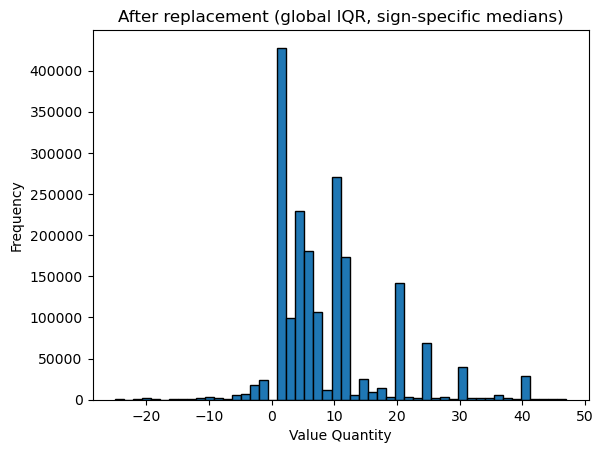

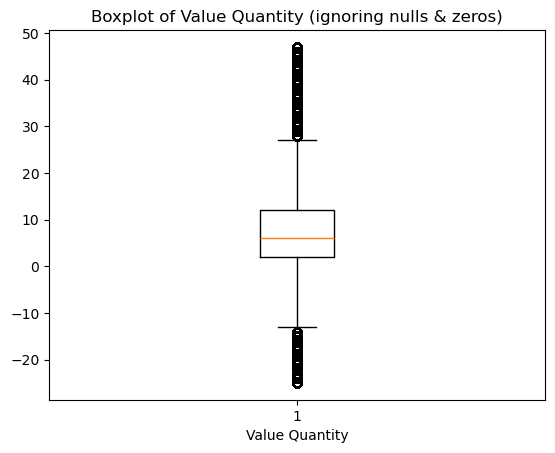

In [55]:
# Keep same global IQR calculation (ignoring nulls & zeros)a
df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]
p25 = df_filtered['value_quantity'].quantile(0.25)
p75 = df_filtered['value_quantity'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['environment_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_quantity'] > 0].groupby(group_cols)['value_quantity'].transform('median')
median_neg = df[df['value_quantity'] < 0].groupby(group_cols)['value_quantity'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_quantity'] > upper_limit       # usually positive outliers
mask_lower = df['value_quantity'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_quantity'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_quantity'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]
plt.hist(df_filtered['value_quantity'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Quantity')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]

plt.boxplot(df_filtered['value_quantity'])
plt.xlabel('Value Quantity')
plt.title('Boxplot of Value Quantity (ignoring nulls & zeros)')
plt.show()
df['value_quantity'].skew()

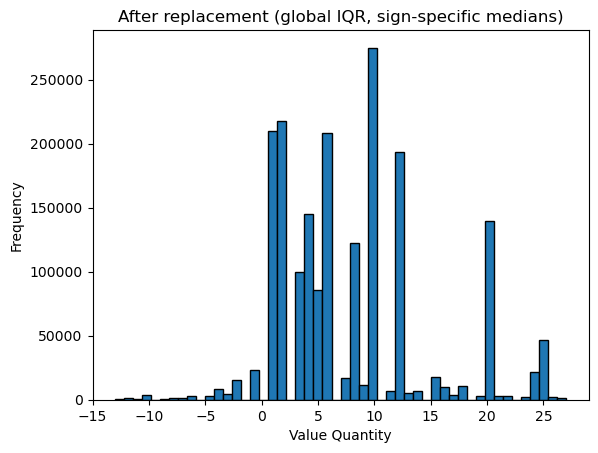

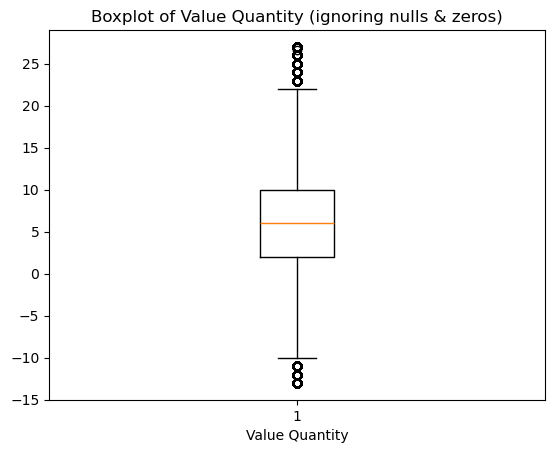

In [56]:
#Running again to fix the skewness
# Keep same global IQR calculation (ignoring nulls & zeros)
df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]
p25 = df_filtered['value_quantity'].quantile(0.25)
p75 = df_filtered['value_quantity'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['environment_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_quantity'] > 0].groupby(group_cols)['value_quantity'].transform('median')
median_neg = df[df['value_quantity'] < 0].groupby(group_cols)['value_quantity'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_quantity'] > upper_limit       # usually positive outliers
mask_lower = df['value_quantity'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_quantity'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_quantity'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]
plt.hist(df_filtered['value_quantity'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Quantity')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_quantity'].notnull() & (df['value_quantity'] != 0)]

plt.boxplot(df_filtered['value_quantity'])
plt.xlabel('Value Quantity')
plt.title('Boxplot of Value Quantity (ignoring nulls & zeros)')
plt.show()
df['value_quantity'].skew()

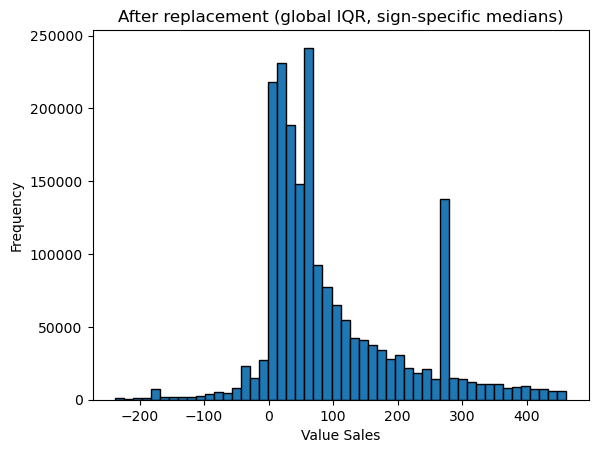

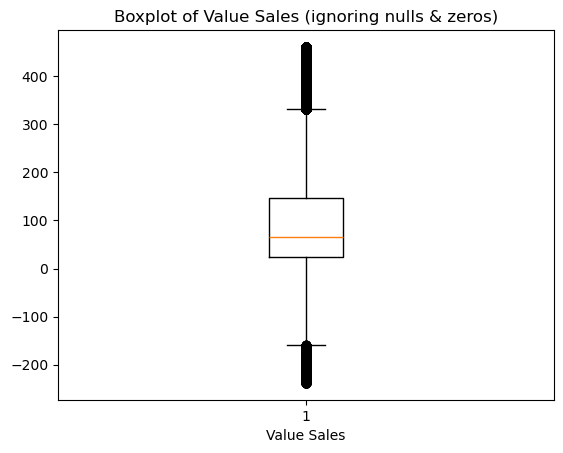

In [57]:
#Fixing the Sales outliers 

# Keep same global IQR calculation (ignoring nulls & zeros)
df_filtered = df[df['value_sales'].notnull() & (df['value_sales'] != 0)]
p25 = df_filtered['value_sales'].quantile(0.25)
p75 = df_filtered['value_sales'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['bonus_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_sales'] > 0].groupby(group_cols)['value_sales'].transform('median')
median_neg = df[df['value_sales'] < 0].groupby(group_cols)['value_sales'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_sales'] > upper_limit       # usually positive outliers
mask_lower = df['value_sales'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_sales'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_sales'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_sales'].notnull()]# & (df['value_sales'] != 0)]
plt.hist(df_filtered['value_sales'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Sales')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_sales'].notnull() & (df['value_sales'] != 0)]

plt.boxplot(df_filtered['value_sales'])
plt.xlabel('Value Sales')
plt.title('Boxplot of Value Sales (ignoring nulls & zeros)')
plt.show()
df['value_sales'].skew()

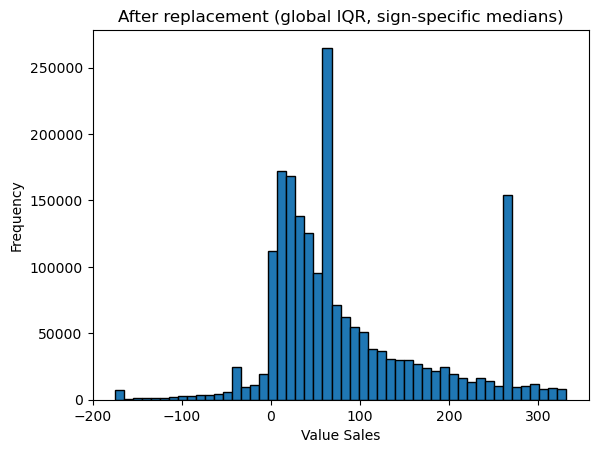

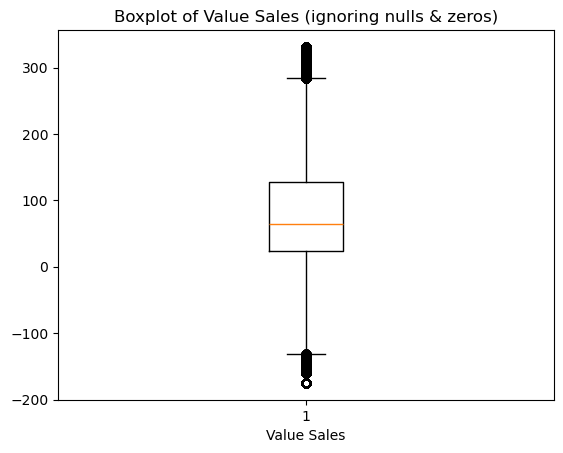

In [58]:
#Moving onto value sales and normalising the data

# Keep same global IQR calculation (ignoring nulls & zeros)
df_filtered = df[df['value_sales'].notnull() & (df['value_sales'] != 0)]
p25 = df_filtered['value_sales'].quantile(0.25)
p75 = df_filtered['value_sales'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['bonus_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_sales'] > 0].groupby(group_cols)['value_sales'].transform('median')
median_neg = df[df['value_sales'] < 0].groupby(group_cols)['value_sales'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_sales'] > upper_limit       # usually positive outliers
mask_lower = df['value_sales'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_sales'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_sales'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_sales'].notnull()]# & (df['value_sales'] != 0)]
plt.hist(df_filtered['value_sales'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Sales')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_sales'].notnull() & (df['value_sales'] != 0)]

plt.boxplot(df_filtered['value_sales'])
plt.xlabel('Value Sales')
plt.title('Boxplot of Value Sales (ignoring nulls & zeros)')
plt.show()
df['value_sales'].skew()

In [59]:
df['value_sales'].skew()

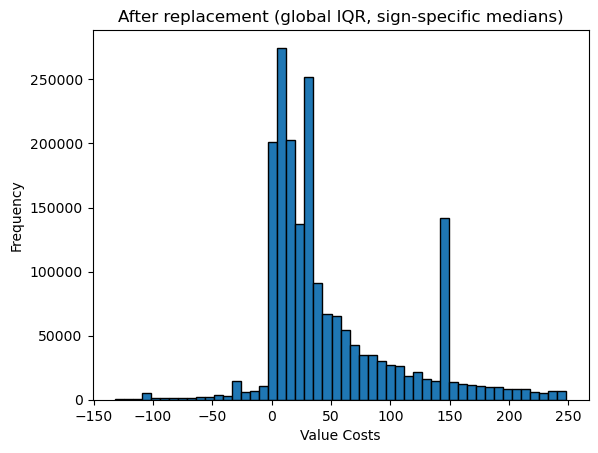

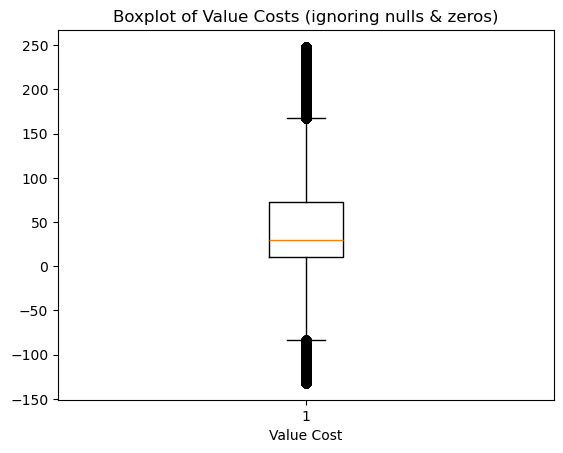

In [60]:
#Moving onto the cost now

# Keep same global IQR calculation (ignoring nulls & zeros)
df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]
p25 = df_filtered['value_cost'].quantile(0.25)
p75 = df_filtered['value_cost'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['bonus_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_cost'] > 0].groupby(group_cols)['value_cost'].transform('median')
median_neg = df[df['value_cost'] < 0].groupby(group_cols)['value_cost'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_cost'] > upper_limit       # usually positive outliers
mask_lower = df['value_cost'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_cost'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_cost'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]
plt.hist(df_filtered['value_cost'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Costs')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]

plt.boxplot(df_filtered['value_cost'])
plt.xlabel('Value Cost')
plt.title('Boxplot of Value Costs (ignoring nulls & zeros)')
plt.show()
df['value_cost'].skew()

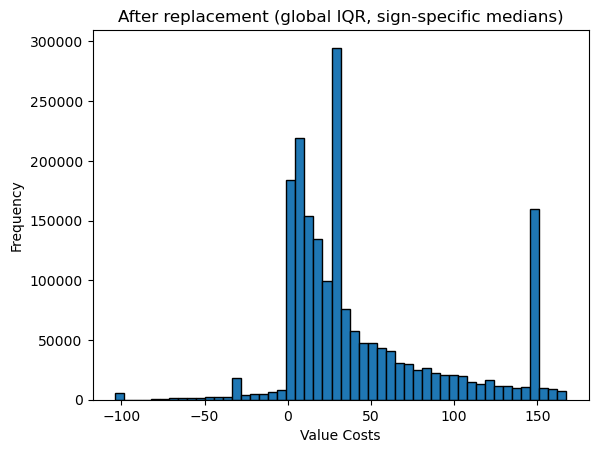

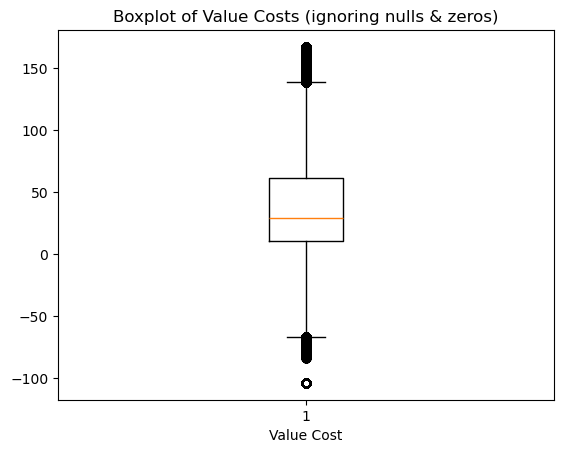

In [61]:
# Keep same global IQR calculation (ignoring nulls & zeros)
df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]
p25 = df_filtered['value_cost'].quantile(0.25)
p75 = df_filtered['value_cost'].quantile(0.75)
iqr = p75 - p25
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print('global p25', p25, 'p75', p75, 'IQR', iqr)
print('global lower_limit', lower_limit, 'upper_limit', upper_limit)

group_cols = ['bonus_group_code']

# Compute medians separately for positive and negative values, aligned to df.index using transform on masked subsets.
median_pos = df[df['value_cost'] > 0].groupby(group_cols)['value_cost'].transform('median')
median_neg = df[df['value_cost'] < 0].groupby(group_cols)['value_cost'].transform('median')

# For rows that are not present in the pos/neg group (NaN in medians), leave as NaN so we don't overwrite with invalid median.
# Identify outliers using global thresholds
mask_upper = df['value_cost'] > upper_limit       # usually positive outliers
mask_lower = df['value_cost'] < lower_limit       # usually negative outliers (or extreme low positives)

# Replace upper outliers with the positive-group median (when available)
replace_upper = mask_upper & median_pos.notnull()
df.loc[replace_upper, 'value_cost'] = median_pos[replace_upper]

# Replace lower outliers with the negative-group median (when available)
replace_lower = mask_lower & median_neg.notnull()
df.loc[replace_lower, 'value_cost'] = median_neg[replace_lower]

print('Replaced upper:', replace_upper.sum(), 'Replaced lower:', replace_lower.sum())

# Recompute filtered dataset for plotting
df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]
plt.hist(df_filtered['value_cost'], bins=50, edgecolor='k')
plt.title('After replacement (global IQR, sign-specific medians)')
plt.xlabel('Value Costs')
plt.ylabel('Frequency')
plt.show()

df_filtered = df[df['value_cost'].notnull() & (df['value_cost'] != 0)]

plt.boxplot(df_filtered['value_cost'])
plt.xlabel('Value Cost')
plt.title('Boxplot of Value Costs (ignoring nulls & zeros)')
plt.show()
df['value_cost'].skew()

In [62]:
df['value_cost'].skew()

In [63]:
#redoing profit after the outlier fix
df['value_profit']=df['value_sales']-df['value_cost']

In [64]:
df.info(show_counts=True)

In [65]:
#quick and dirty grab after the outliers are fixed
df.to_csv('cleaned_outliers_excluded.csv', index=False)

In [66]:
df_cleaned = pd.read_csv("cleaned_outliers_excluded.csv", low_memory=False)

In [67]:
df_cleaned.head(10)

# Section 2: Exploratory Insights (all the codes in one cell - do not insert extra cells) 

## section 2.1 Sales Share by Region

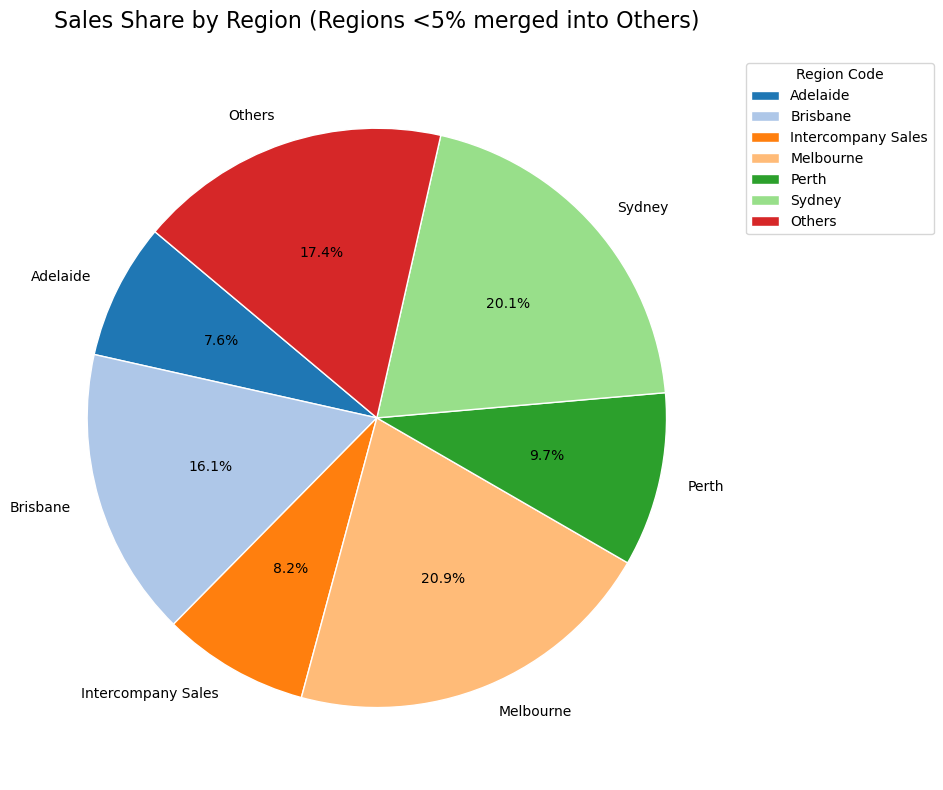

In [68]:
# Calculate total sales and share by region
total_sales = df_cleaned['value_sales'].sum()

# Group by customer_district_code and sum
sales_by_district = df_cleaned.groupby('customer_district_name')['value_sales'].sum().reset_index()

# Group by customer_district_code and sum
sales_by_district['percentage'] = (sales_by_district['value_sales'] / total_sales) * 100

# Regions with less than 5% are classified as "Others"
threshold = 5 
small_districts = sales_by_district[sales_by_district['percentage'] < threshold]
large_districts = sales_by_district[sales_by_district['percentage'] >= threshold]

# Calculate Others rows
others_sales = small_districts['value_sales'].sum()
others_percentage = (others_sales / total_sales) * 100

others_row = pd.DataFrame({
    'customer_district_name': ['Others'],
    'value_sales': [others_sales],
    'percentage': [others_percentage]
})

# Merge data
final_sales = pd.concat([large_districts, others_row], ignore_index=True)


# Draw a pie chart
plt.figure(figsize=(10, 8)) 

plt.pie(
    final_sales['value_sales'],
    labels=final_sales['customer_district_name'], 
    autopct=lambda p: f'{p:.1f}%' if p >= threshold else '', 
    startangle=140,  
    colors=plt.cm.tab20.colors,  
    wedgeprops={'edgecolor': 'white'} 
)

# Add title and legend
plt.title('Sales Share by Region (Regions <5% merged into Others)', fontsize=16, pad=20)
plt.legend(
    title='Region Code',
    labels=final_sales['customer_district_name'],
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=10
)

plt.tight_layout() 
plt.show()


## section 2.2 T-Test for Average Sales Difference by Order Type

In [69]:
# Extract sales of two types of orders
nor_sales = df_cleaned[df_cleaned['order_type_code'] == 'NOR']['value_sales']
pro_sales = df_cleaned[df_cleaned['order_type_code'] == 'PRO']['value_sales']

# Check data description
print('Normal Orders (NOR) - Sales Summary:')
print(nor_sales.describe())
print('\nProject Orders (PRO) - Sales Summary:')
print(pro_sales.describe())


# Perform a two-sample t-test
# Hypothesis:
# H0: The average sales of NOR and PRO are the same (no significant difference)
# H1: The average sales of NOR and PRO are different (significant difference)
t_stat, p_value = stats.ttest_ind(nor_sales, pro_sales, equal_var=False)

print('\nT-test Results:')
print(f't-statistic = {t_stat:.2f}')
print(f'p-value = {p_value:.2f}')

# Conclusion Explanation
alpha = 0.05
if p_value < alpha:
    print('Conclusion: H0 is rejected, there is a significant difference in the average sales of the two types of orders.')
else:
    print('Conclusion: H0 cannot be rejected, there is no significant difference in the average sales of the two types of orders.')


Normal Orders (NOR) - Sales Summary:
count    1.609583e+06
mean     8.688395e+01
std      8.211261e+01
min     -1.750000e+02
25%      2.600000e+01
50%      6.490000e+01
75%      1.188450e+02
max      3.312000e+02
Name: value_sales, dtype: float64

Project Orders (PRO) - Sales Summary:
count    29018.000000
mean       198.626556
std         93.387312
min          0.000000
25%         88.430000
50%        266.590000
75%        266.590000
max        331.200000
Name: value_sales, dtype: float64

T-test Results:
t-statistic = -202.42
p-value = 0.00
Conclusion: H0 is rejected, there is a significant difference in the average sales of the two types of orders.


## section 2.3 Top 5 Business Areas by Sales Value

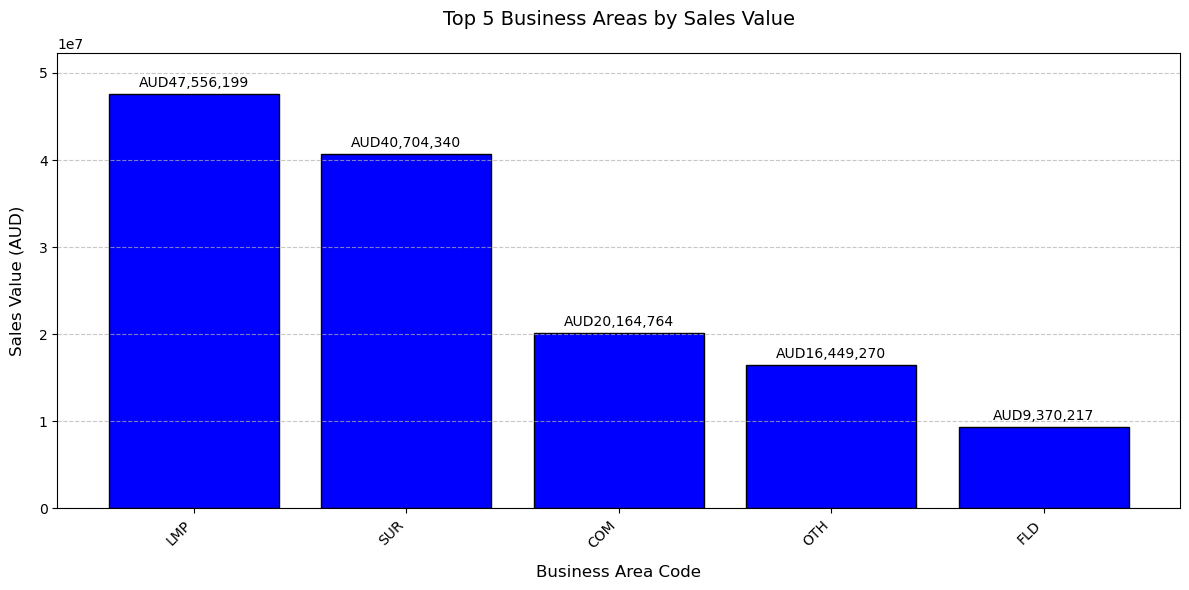

In [70]:
# Calculate total sales by grouping by business_area_code
business_sales = df_cleaned.groupby('business_area_code')['value_sales'].sum().reset_index()

# Select the top 5 business areas with the highest sales
top5_business = business_sales.sort_values(by='value_sales', ascending=False).head(5)

# Draw a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(
    x=top5_business['business_area_code'], 
    height=top5_business['value_sales'], 
    color='blue', edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width()/2, 
        y=height + max(top5_business['value_sales'])*0.01, 
        s=f'AUD{height:,.0f}', 
        ha='center', 
        va='bottom',
        fontsize=10
    )

plt.title('Top 5 Business Areas by Sales Value', fontsize=14, pad=20)
plt.xlabel('Business Area Code', fontsize=12, labelpad=10)
plt.ylabel('Sales Value (AUD)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, max(top5_business['value_sales'])*1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## section 2.4 Bottom 5 Business Areas by Sales Value

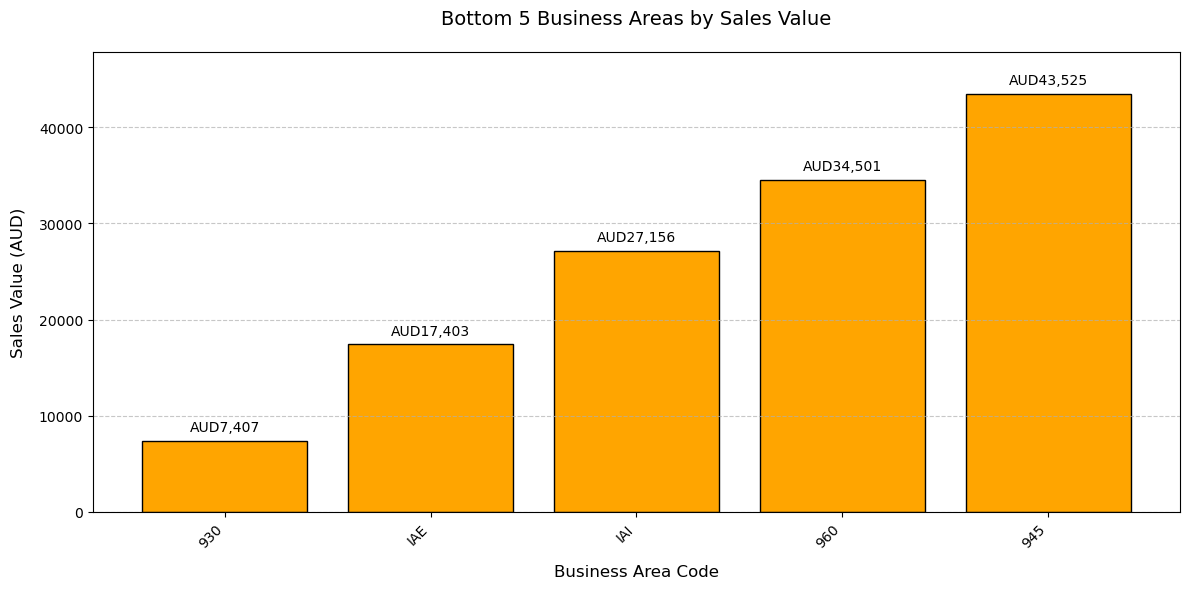

In [71]:
# Calculate total sales by grouping by business_area_code
business_sales = df_cleaned.groupby('business_area_code')['value_sales'].sum().reset_index()

# Select the bottom 5 business areas with the highest sales
bottom5_business = business_sales.sort_values(by='value_sales', ascending=True).head(5)

# Draw the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(
    x=bottom5_business['business_area_code'], 
    height=bottom5_business['value_sales'], 
    color='orange', 
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width()/2, 
        y=height + max(bottom5_business['value_sales'])*0.05,
        s=f'AUD{height:,.0f}', 
        ha='center', 
        va='top',
        fontsize=10
    )


plt.title('Bottom 5 Business Areas by Sales Value', fontsize=14, pad=20)
plt.xlabel('Business Area Code', fontsize=12, labelpad=10)
plt.ylabel('Sales Value (AUD)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, max(bottom5_business['value_sales'])*1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## section 2.5 Monthly Sales Trend Comparison

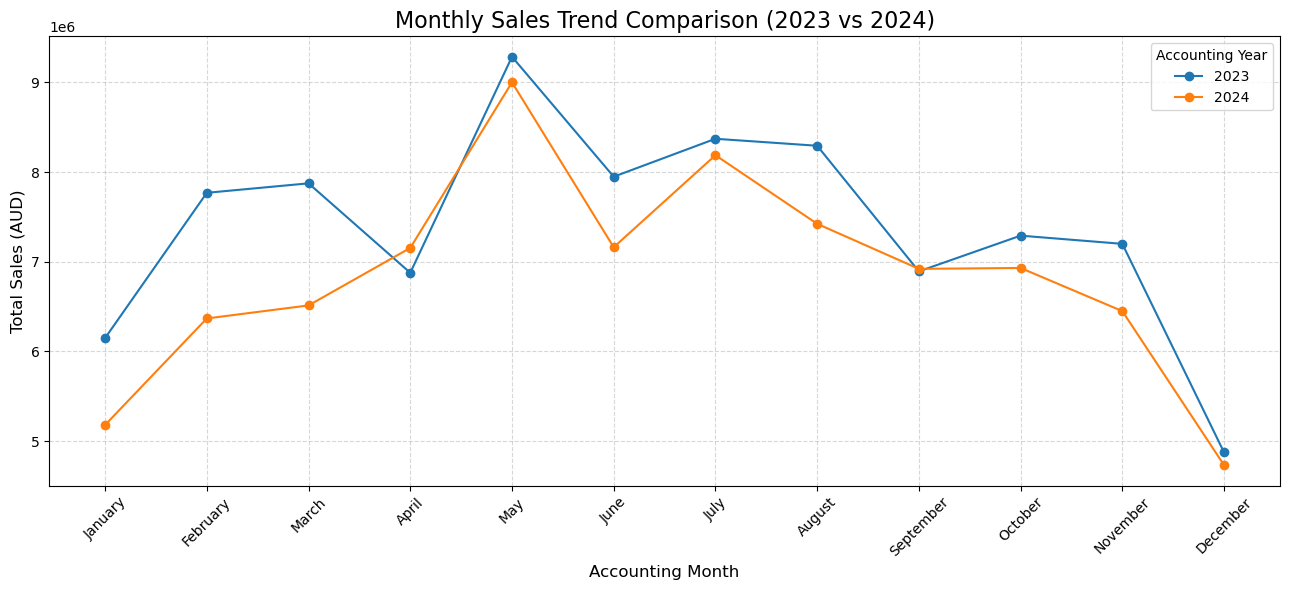

In [72]:
import calendar


#Giving the month a name for the graphs
df_cleaned['month_names'] = df_cleaned['account_month'].apply(lambda x: calendar.month_name[x])

# Summarize sales by fiscal_year and fiscal_month
monthly_sales = df_cleaned.groupby(['account_year', 'month_names'])['value_sales'].sum().reset_index()
   # Define month order
month_order = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
   
# Add a numeric month column for sorting
monthly_sales['month_num'] = monthly_sales['month_names'].map(month_order)
   
# Sort by year and month number
monthly_sales = monthly_sales.sort_values(by=['account_year', 'month_num'])

# Draw a line chart
plt.figure(figsize=(13, 6))


# Get all years
years = monthly_sales['account_year'].unique()

# draw a line for each year
for year in years:
    year_data = monthly_sales[monthly_sales['account_year'] == year]
    plt.plot(
        year_data['month_names'], 
        year_data['value_sales'], 
        marker='o', 
        label=str(year)
    )

# Add title and axis labels
plt.title('Monthly Sales Trend Comparison (2023 vs 2024)', fontsize=16)
plt.xlabel('Accounting Month', fontsize=12)
plt.ylabel('Total Sales (AUD)', fontsize=12)
plt.legend(title='Accounting Year')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(list(month_order.keys()), rotation=45)
plt.tight_layout()
plt.show()


# Section 3: Test Sub Sample Differences (all the codes in one cell - do not insert extra cells) 

## section 3.1: Product Category Performance During Peak vs Off-Peak Seasons

**Business Question:**  
 Does LuminaTech experience higher average sales in the three months leading up to and including EOFY (Apr–Jun),compared to the rest of the year?
**Rationale:**  
LuminaTech wants to understand whether certain product category is more sensitive to seasonal demand.
If certain products perform better during EOFY (April, May, June), management can align marketing campaigns, inventory levels, and production schedules accordingly.

**Hypotheses:**  
H₀: μ_peak = μ_offpeak → There is no significant difference in mean sales between EOFY months (Apr–Jun) and the rest of the year.

H₁: μ_peak ≠ μ_offpeak → There is a significant difference in mean sales between EOFY months and the rest of the year.


In [73]:
# Define EOFY and Non-EOFY months (Apr–Jun = 4,5,6)
def get_eofy_season(month):
    if month in [4, 5, 6]:
        return "EOFY"
    else:
        return "Non-EOFY"

df_cleaned["season"] = df_cleaned["fiscal_month"].apply(get_eofy_season)

# Choose main product categories (based on 'business_area_code', which has over 800000 items sold-> best seller)
main_cats = ["LMP", "SUR", "DLT", "FLD", "OTH"]
df_cleaned_cat = df_cleaned[df_cleaned["business_area_code"].isin(main_cats)]

# Compute total sales per category per season
sales_summary = (df_cleaned_cat.groupby(["business_area_code", "season"])["value_sales"].sum().reset_index())

# Run t-tests for each product category
results = []
for cat in main_cats:
    eofy = df_cleaned_cat[(df_cleaned_cat["business_area_code"]==cat) & (df_cleaned_cat["season"]=="EOFY")]["value_sales"]
    non  = df_cleaned_cat[(df_cleaned_cat["business_area_code"]==cat) & (df_cleaned_cat["season"]=="Non-EOFY")]["value_sales"]
    if len(eofy)>1 and len(non)>1:
        t_stat, p_val = stats.ttest_ind(eofy,non, equal_var=False)

# Display results
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

# Interpretation rule
# Significance level 5%, Confidence level 95%
alpha = 0.05
if p_val < alpha:
    print(f"Result: Reject H₀ (p < {alpha}). There is a significant difference in mean sales between EOFY months (Apr–Jun) and the rest of the year.")
else:
    print(f"Result: Fail to reject H₀ (p ≥ {alpha}). The data does not provide sufficient evidence that the monthly sales between EOFY (April-June) and Non-EOFY seasons are significantly different.")

T-statistic: -0.984
P-value: 0.3251
Result: Fail to reject H₀ (p ≥ 0.05). The data does not provide sufficient evidence that the monthly sales between EOFY (April-June) and Non-EOFY seasons are significantly different.


Interpretation:
The t-test comparing average sales during the EOFY (April–June) period and the rest of the year shows no statistically significant difference (t = -0.984, p = 0.3251). Therefore, we fail to reject the null hypothesis (H₀). This indicates that LuminaTech’s sales do not experience a significant increase during the EOFY period compared to other months. In other words, while EOFY is typically a strong sales period for many industries, it does not appear to be a major demand driver for lighting products.

Management Insight: Marketing and sales resources should not be concentrated solely on EOFY campaigns. Instead, LuminaTech should maintain a consistent marketing presence throughout the year, targeting project timelines and contract opportunities rather than seasonal promotions. The company could still run targeted EOFY offers for commercial clients, but these should complement,not replace, ongoing B2B engagement strategies.

## Section 3.2: Are average sales higher for URB (Urban Amenity) products than for 910 (Industrial) products?

H₀: μ_URB = μ_910 → There is no significant difference in mean sales between Urban Amenity (URB) and Industrial (910) products.  
H₁: μ_URB ≠ μ_910 → There is a significant difference in mean sales between Urban Amenity (URB) and Industrial (910) products.


In [74]:
from scipy import stats

# Define the two samples
urb_sales = df_cleaned[df_cleaned['business_area_code']=='URB']['value_sales']
ind_sales = df_cleaned[df_cleaned['business_area_code']=='910']['value_sales']

# Run two-sample t-test
t_stat, p_val = stats.ttest_ind(ind_sales,urb_sales, equal_var=False)

# Display results
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

# Interpretation rule
# Significance level 5%, Confidence level 95%
alpha = 0.05
if p_val < alpha:
    print(f"Result: Reject H₀ (p < {alpha}). There is a significant difference between the mean sales of URB (Urban Amenity) products and 910 (Industrial) products.")
else:
    print(f"Result: Fail to reject H₀ (p ≥ {alpha}). The data does not provide sufficient evidence that the mean sales between the mean sales of URB (Urban Amenity) products and 910 (Industrial) products are significantly different.")

T-statistic: 14.697
P-value: 0.0000
Result: Reject H₀ (p < 0.05). There is a significant difference between the mean sales of URB (Urban Amenity) products and 910 (Industrial) products.


Interpretation:
The t-test result (t = 14.697, p = 0.0000) indicates a statistically significant difference in average sales between Urban Amenity (URB) and Industrial (910) product groups.  
Industrial segment products show higher mean sales, suggesting stronger demand in urban infrastructure and architectural lighting projects.  

Management Insight:  
Management can leverage this finding to prioritise product development and sales resources towards the Industrial segment, which demonstrates greater market potential and pricing resilience.


## Section 3.3: Are the average sales of the Top 5 and Bottom 5 business areas statistically different?

**Hypotheses**  

H₀: μ_top = μ_bottom:  There is no significant difference in average sales between the top 5 and the bottom 5 business areas.

H₁: μ_top ≠ μ_bottom: There is a significant difference in average sales between the two groups.


In [75]:
from scipy import stats
import pandas as pd

# Aggregate sales by business_area_code
business_sales = df_cleaned.groupby('business_area_code')['value_sales'].sum().reset_index()

# Identify top and bottom 5
top5_codes = business_sales.sort_values('value_sales', ascending=False).head(5)['business_area_code'].tolist()
bottom5_codes = business_sales.sort_values('value_sales', ascending=True).head(5)['business_area_code'].tolist()

print("Top 5 business areas:", top5_codes)
print("Bottom 5 business areas:", bottom5_codes, "\n")

# Extract transactional-level sales for those categories
top_sales = df_cleaned[df_cleaned['business_area_code'].isin(top5_codes)]['value_sales']
bottom_sales = df_cleaned[df_cleaned['business_area_code'].isin(bottom5_codes)]['value_sales']

# Run Welch’s t-test
t_stat, p_val = stats.ttest_ind(top_sales, bottom_sales, equal_var=False, nan_policy='omit')
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

# Interpretation rule
# Significance level 5%, Confidence level 95%
alpha = 0.05
if p_val < alpha:
    print(f"Result: Reject H₀ (p-value < {alpha}). There is a significant difference between the mean sales of top 5 and bottom 5 business areas.")
else:
    print(f"Result: Fail to reject H₀ (p-value ≥ {alpha}). The data does not provide sufficient evidence that the mean sales between top 5 and bottom 5 groups are significantly different .")

Top 5 business areas: ['LMP', 'SUR', 'COM', 'OTH', 'FLD']
Bottom 5 business areas: ['930', 'IAE', 'IAI', '960', '945'] 

T-statistic: -25.497
P-value: 0.0000
Result: Reject H₀ (p-value < 0.05). There is a significant difference between the mean sales of top 5 and bottom 5 business areas.


Interpretation: 
The t-test indicates a statistically significant difference in average sales between the top 5 and bottom 5 business areas.
This confirms that LuminaTech’s high-performing product categories ('SUR', 'LMP', 'RWY', 'COM', 'DLT') generate substantially higher sales than the lowest-performing ones, suggesting a real performance gap.

Management Insight: 
LuminaTech should investigate why the bottom categories underperform, like limited market demand, pricing strategy, or distribution coverage and consider resource reallocation or product rationalisation. Stock up more top 5 business areas.


# Section 4: Inference (in this section, add as many cells as you need) 

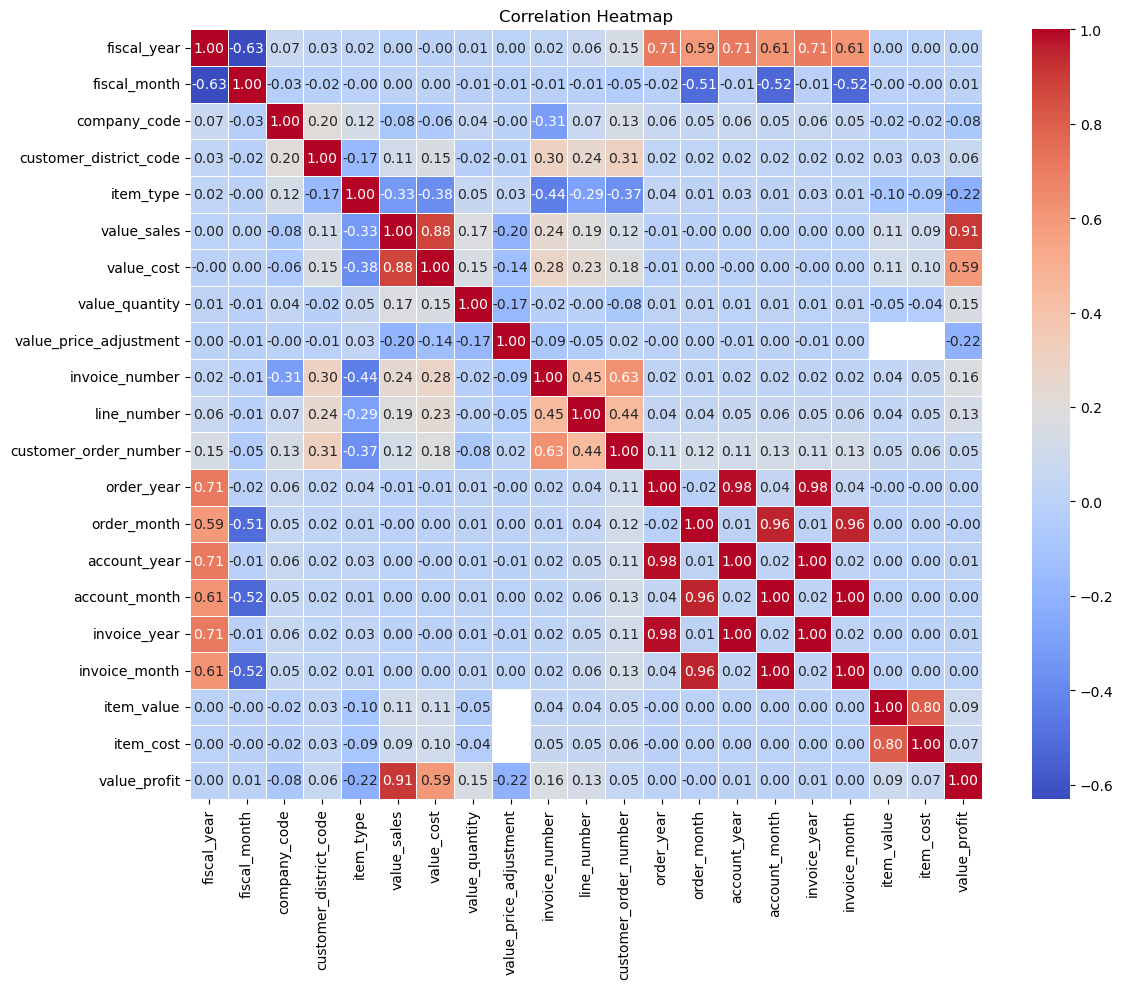

In [76]:
display(Markdown("## The Correlation Matrix:"))
#Correlation matrix
# Select numeric columns
numeric_cols = df_cleaned.select_dtypes(include=['float64','int64']).columns

# Calculate correlation matrix
corr = df_cleaned[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# sns.pairplot(df, diag_kind='kde')

## Data preparation (one-hot coding)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [78]:
# Choose variables for regression
regression_df_cleaned = df_cleaned[['value_profit','value_price_adjustment',
                     'warehouse_code_meta', 'item_type','currency']].copy()

In [79]:
# Ensure numeric
regression_df_cleaned['value_profit'] = pd.to_numeric(regression_df_cleaned['value_profit'], errors='coerce')
regression_df_cleaned['value_price_adjustment'] = pd.to_numeric(regression_df_cleaned['value_price_adjustment'], errors='coerce')

In [80]:
# One-hot encoding 
regression_df_cleaned = pd.get_dummies(regression_df_cleaned, 
                                columns=['warehouse_code_meta','currency','item_type'], 
                                drop_first=True, 
                                dtype=float)

In [81]:
print("Dataset shape:", regression_df_cleaned.shape)
print("\nColumns after one-hot encoding:")
print(regression_df_cleaned.columns.tolist())

## Multiple linear regression model 

In [82]:
# Define X and y
X = regression_df_cleaned.drop('value_profit', axis=1)
y = regression_df_cleaned['value_profit']

In [83]:
# Ensure X is float type
X = X.astype(float)

# Add constant
X_with_const = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_with_const).fit()

In [84]:
# Print model summary
print("\n" + "="*80)
print("REGRESSION MODEL SUMMARY")
print("="*80)
print(model.summary())

## Multiple linear regression assumption checking

### Multicolinearity

In [90]:
# Calculate VIF for all variables in X
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.to_string(index=False))

### Normality of Residuals

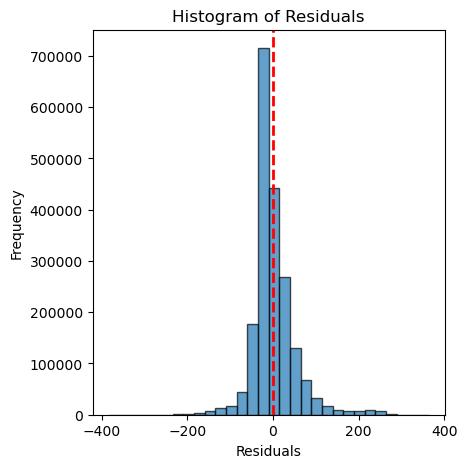

In [85]:
residuals = model.resid

# Histogram
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.axvline(residuals.mean(), color='red', linestyle='--', linewidth=2)

### Homoscedasticity

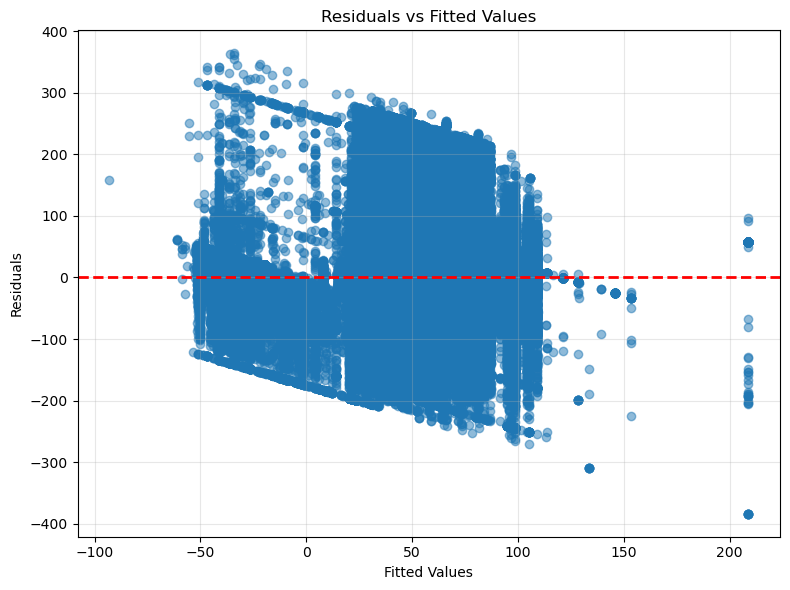

In [86]:
fitted_values = model.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Linerarity



In [89]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Sample data
sample_df = regression_df_cleaned.sample(n=10000, random_state=42)

# Grid layout
n_features = len(X.columns)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    x = sample_df[col]
    y = sample_df['value_profit']
    
    axes[i].scatter(x, y, alpha=0.5, s=20)
    
    try:
        slope, intercept, r_value, _, _ = linregress(x, y)
        x_sorted = np.sort(x)
        axes[i].plot(x_sorted, slope * x_sorted + intercept, 'r-', linewidth=2)
    except:
        pass  # Skip if regression fails
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('value_profit')
    axes[i].set_title(f'{col} vs Profit')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()